### Libraries

In [1]:
using LinearAlgebra          ### Linear algebra library
using PyPlot
using DifferentialEquations  ### Library to use differential equations
using StaticArrays
using DelimitedFiles
#n_threads = Threads.nthreads() ##= 4
println("Number of threads with JUlIA_NUM used in operations is : " , Threads.nthreads() )
println("Number of threads with BLAS used in operations is : " , BLAS.get_num_threads() )
⊗(A,B) = kron(A,B) ;

Number of threads with JUlIA_NUM used in operations is : 1
Number of threads with BLAS used in operations is : 1


## Auxiliary functions

In [2]:
@inline function get_sub(idx::Int, sub_dim::Int)
    ### Get the sub index range 
    a = (idx-1)*sub_dim + 1
    b = idx*sub_dim
    return a:b
end
function fermi(ϵ;β=1)
    ### Fermi function 
   fermi = 1. / (1. + exp(ϵ*β))
   #ϵ> 36 ? 0.0 : (ϵ < -36 ? 1.0 : 1.0/(1.0 + exp(ϵ)))
end

@inline ϵ_n(n::Int,Ny::Int ;γ::Float64 = 1.0) = -2*γ*cos(n*pi/(Ny+1))  ### Nc is is Ny*Nσ

function cal_G_scalar(z, Al, xl)
    G_z = 0.0
    for i in 1:length(xl)
        G_z += Al[i] / (z - xl[i]) + conj(Al[i]) / (z - conj(xl[i]) )
    end
    return G_z
end

function pade_poles(M::Int)
    ### Calculates the residue and poles of the pade decomposition 
    @assert M ≥ 1 "The number of poles should be greater or equal than 1"
    M=2*M
    # Symmetric tridiagonal with off-diagonals b_n = 1 / (2*sqrt(4n^2 - 1))
    b = [1.0/(2*sqrt(4n^2 - 1.0)) for n in 1:M-1]
    T = SymTridiagonal(zeros(M), b)        # main diagonal zeros, off-diagonals b
    F = eigen(T)                           # F.values::Vector, F.vectors::Matrix
    λ = F.values
    V = F.vectors
    # keep positive eigenvalues
    pos = findall(>(0.0), λ)
    ξ = 1 ./λ[pos]                       # poles (imag-axis locations)
    η = norm.(V[1, pos]).^2 ./ (4.0*λ[pos].^2)             # weights = (first component)^2
    return -1im*ξ, η #### noth
end

pade_poles (generic function with 1 method)

## Self Energy Poles

In [3]:
data_z = readdlm("z_Self.txt")  # matriz N×2
data_R = readdlm("R_Self.txt")  # matriz N×2
zλ1 = complex.(data_z[:, 1], data_z[:, 2])  # Vector{ComplexF64}
Rλ1 = complex.(data_R[:, 1], data_R[:, 2]) ; # Vector{ComplexF64};
zλ2,Rλ2 = pade_poles(20) ### we use 20 poles for the fermi decomposition
#### We set the poles with our corresponding values
Rλ1 = Rλ1*2pi ;
Rλ2 =  -Rλ2 ### 

Rλ = [Rλ1;  Rλ2]
zλ = [zλ1;  zλ2]

@inline Γ_r(w) =   cal_G_scalar( w, Rλ1, zλ1) ### Recontructed Γ function 

println("Number of MPM poles from Gull's code :",length(Rλ1))
println("Number of Pade poles :",length(Rλ2))
println("Total number of poles  :",length(Rλ))

Number of MPM poles from Gull's code :49
Number of Pade poles :20
Total number of poles  :69


## Building function to precalculated quantities

In [4]:



function build_Σᴸ_nλ(Rλ::Vector{ComplexF64}, zλ::Vector{ComplexF64}, Ny::Int, Nσ::Int, N_orb::Int, Nλ1::Int, Nλ2::Int ; β::Float64=1)
    ### This function creates an instance of the effective residues 
    ### of the lesser component Σ in the diagonal basis
    # Note that for square lattice selfenergy 
    # all the elements can be builded from the semicircle leveldiwth function 
    # Note that for both spin up and spin down the system should be repeated for nonmagnetic leads
    Nλ         = Nλ1 + Nλ2
    Nc         = Ny*Nσ*N_orb
    dims_Σᴸ_nλ = (Nc, Nλ)
    Σᴸ_nλ      = zeros(ComplexF64, dims_Σᴸ_nλ)
    
    ### 
    for i in 1:Ny
        n_idx = get_sub(i, Nσ*N_orb)
        ### Run over the poles of the fermi function 
        for λ1 in 1:Nλ1
            Σᴸ_nλ[n_idx,λ1] .= Rλ[λ1]*fermi( zλ[λ1]+ϵ_n(i,Ny) ,β=β )
        end
        ### Run over the poles of the fermi function 
        for λ2 in Nλ1+1:Nλ
            Σᴸ_nλ[n_idx,λ2] .= (Rλ[λ2]/β)*Γ_r(zλ[λ2]/β-ϵ_n(i,Ny)) #*4pi#Γ(zλ[λ2],i,Ny)
        end
    end
    return Σᴸ_nλ
end

function build_Σᴳ_nλ(Rλ::Vector{ComplexF64}, zλ::Vector{ComplexF64}, Ny::Int, Nσ::Int, N_orb::Int, Nλ1::Int, Nλ2::Int ;β::Float64=1.0)
    Nλ         = Nλ1 + Nλ2
    Nc         = Ny*Nσ*N_orb
    dims_Σᴳ_nλ = (Nc, Nλ)
    Σᴳ_nλ      = zeros(ComplexF64, dims_Σᴳ_nλ)
    ### 
    for i in 1:Ny
        n_idx = get_sub(i, Nσ*N_orb)
        ### Run over the poles of the fermi function 
        for λ1 in 1:Nλ1
            Σᴳ_nλ[n_idx,λ1] .= -Rλ[λ1]*(1-fermi( zλ[λ1]+ϵ_n(i,Ny), β=β )) ### Note the beta function 
        end
        ### Run over the poles of the fermi function 
        for λ2 in Nλ1+1:Nλ
            Σᴳ_nλ[n_idx,λ2] .= (Rλ[λ2]/β )*Γ_r(zλ[λ2]/β-ϵ_n(i,Ny))
        end
    end
    return Σᴳ_nλ
end

function build_χ_nλ(zλ::Vector{ComplexF64}, Ny::Int, Nσ::Int, N_orb::Int, Nλ1::Int, Nλ2::Int; β=1.0)
    Nλ         = Nλ1 + Nλ2
    Nc         = Ny*Nσ*N_orb
    dims_χ_nλ = (Nc, Nλ)
    χ_nλ      = zeros(ComplexF64, dims_χ_nλ)
    for i in 1:Ny
        n_idx = get_sub(i, Nσ*N_orb)   # vector o rango de índices locales
        for n in n_idx
            χ_nλ[n, 1:Nλ1]      .= zλ[1:Nλ1] .+ ϵ_n(i,Ny)
            χ_nλ[n, Nλ1+1:Nλ]   .= zλ[Nλ1+1:Nλ] / β  # o sin /β si ya están en energía
        end
    end
    return χ_nλ
end

function build_ξ_an(Nx::Int, Ny::Int, Nσ::Int, N_orb::Int;
                           xcol::Int, y_coup = 1:Ny)
    """
    Construye ξ_an para un lead acoplado a la columna x = xcol
    y a los sitios y en `y_coup` (por defecto, todos 1:Ny).
    """
    Nloc = Nσ * N_orb           # DOFs por sitio
    Ns   = Nx * Ny * Nloc
    Nc   = Ny * Nloc            # Ny modos × (spin×orb)
    ξ_an = zeros(ComplexF64, Ns, Nc)

    for y in y_coup
        # índice global de sitio (xcol, y)
        i = (xcol - 1) * Ny + y
        # DOFs locales del sitio (xcol,y)
        i_idx = get_sub(i, Nloc)  # típicamente (i-1)*Nloc+1 : i*Nloc
        for ny_mode in 1:Ny
            amp = sqrt(2/(Ny+1)) * sin(ny_mode * y * pi/(Ny+1))
            for (α, row) in enumerate(i_idx)
                n = (ny_mode - 1)*Nloc + α   # índice de canal global
                ξ_an[row, n] = amp
            end
        end
    end
    return ξ_an
end


build_ξ_an (generic function with 1 method)

## Building functions for the Hamiltonian

In [19]:
# println(sqrt(2/(2+1)) * sin(1 * 1 * pi/(2+1)))
# println(sqrt(2/(2+1)) * sin(2 * 1 * pi/(2+1)))

In [20]:
# println(sqrt(2/(2+1)) * sin(1 * 2 * pi/(2+1)))
# println(sqrt(2/(2+1)) * sin(2 * 2 * pi/(2+1)))

In [5]:
σ_0 = @SMatrix [1.0 0.0; 0.0 1.0]
σ_x = @SMatrix [0.0 1.0; 1.0 0.0]
σ_y = @SMatrix [0.0 -1im; 1im 0.0]
σ_z = @SMatrix [1.0 0.0; 0.0 -1.0]

#### Building the Hamiltonian 
function build_blocks(;Ny=1,Nσ=2,N_orb=1,γ=1,γso=0.0 + 1im*0.0)
    #γ::Float64,γso::ComplexF64,Bz::Float64,ny::Int)
    "Creates the building blocks for a general nx x ny square lattice "
    N_b = Ny*Nσ*N_orb # We include the spin degree of freedom 
    ######
    H0  = zeros(ComplexF64,N_b,N_b)
    T   = zeros(ComplexF64,N_b,N_b)
    I_y = Matrix{ComplexF64}(I,Ny,Ny)
    ######
    Ty  = diagm(-1 =>  ones(Ny-1) )
    T0  = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' #-Bz*kron(One_y, σ_z)
    ######
    T .= (I_y)⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end

function build_H_ab(;Nx=1,Ny=1,Nσ=2,N_orb=1,γ=1.0,γso=0.0 + 1im*0.0)
    "This function builds the central hamiltonian for an square lattice"
    #γ::Float64,γso::ComplexF64,Bz::Float64,nx::Int,ny::Int)
    Ns  = Nx*Ny*Nσ*N_orb
    HC  = zeros(ComplexF64,Ns,Ns)
    I_x =  Matrix{ComplexF64}(I,Nx,Nx)
    #One_x = Diagonal(ones(nx))
    H0,T = build_blocks(;Ny, Nσ, N_orb, γ, γso)
    Tx   = diagm( -1 =>  ones(Nx-1))⊗T 
    HC   = I_x⊗H0 + Tx + Tx'
    return HC
end

build_H_ab (generic function with 1 method)

## Structure with parameters and Dynamical variables 

In [6]:
#### Structure with the parameters of the system 
Base.@kwdef struct ModelParamsTDNEGF
    ### Structure storing all the parameters of the system 
    # Sizes of the dimension
    Nx::Int = 2
    Ny::Int = 2
    N_sites::Int = Nx*Ny
    Nσ::Int = 2
    N_orb::Int = 1
    Nα::Int = 2
    Ns::Int = Nx*Ny*Nσ*N_orb
    N_loc::Int = Nσ*N_orb ### Local degrees of freedom 
    # Number of channels 
    Nc::Int = Ny*Nσ*N_orb       
    # Number of poles in MPM decomposition 
    N_λ1::Int
    # Number of poles in pade for fermi function 
    N_λ2::Int
    # Total number of poles 
    N_λ::Int = N_λ1 + N_λ2
    ### 
    dims_Ω_nλ1α_nλ1α::NTuple{6, Int64} = (Nc, N_λ1, Nα, Nc, N_λ1, Nα)
    dims_Ω_nλ1α_nλ2α::NTuple{6, Int64} = (Nc, N_λ1, Nα, Nc, N_λ2, Nα)
    dims_Ω_nλ2α_nλ1α::NTuple{6, Int64} = (Nc, N_λ2, Nα, Nc, N_λ1, Nα)
    dims_Ψ_anλα::NTuple{4, Int64}      = (Ns, Nc, N_λ,  Nα )
    dims_ρ_ab::NTuple{2, Int64}        = (Ns, Ns)
    ###
    size_Ω_nλ1α_nλ1α::Int64 = prod(dims_Ω_nλ1α_nλ1α)
    size_Ω_nλ1α_nλ2α::Int64 = prod(dims_Ω_nλ1α_nλ2α)
    size_Ω_nλ2α_nλ1α::Int64 = prod(dims_Ω_nλ2α_nλ1α)
    size_Ψ_anλα::Int64      = prod(dims_Ψ_anλα)
    size_ρ_ab::Int64        = prod(dims_ρ_ab)
    size_u::Int64           = size_ρ_ab + size_Ψ_anλα + size_Ω_nλ1α_nλ1α + size_Ω_nλ1α_nλ2α + size_Ω_nλ2α_nλ1α
    ### 
    idx_ρ_ab::UnitRange{Int64}         = 1:size_ρ_ab
    idx_Ψ_anλα::UnitRange{Int64}       = size_ρ_ab + 1 : size_Ψ_anλα + size_ρ_ab 
    idx_Ω_nλ1α_nλ1α::UnitRange{Int64}  = size_ρ_ab + size_Ψ_anλα + 1 :  size_ρ_ab + size_Ψ_anλα + size_Ω_nλ1α_nλ1α
    idx_Ω_nλ1α_nλ2α::UnitRange{Int64}  = size_ρ_ab + size_Ψ_anλα + size_Ω_nλ1α_nλ1α + 1 : size_ρ_ab + size_Ψ_anλα + size_Ω_nλ1α_nλ1α + size_Ω_nλ1α_nλ2α
    idx_Ω_nλ2α_nλ1α::UnitRange{Int64}  = size_ρ_ab + size_Ψ_anλα + size_Ω_nλ1α_nλ1α + size_Ω_nλ1α_nλ2α + 1 : size_ρ_ab + size_Ψ_anλα + size_Ω_nλ1α_nλ1α + size_Ω_nλ1α_nλ2α + size_Ω_nλ2α_nλ1α
    ### Static precalculated objects
    σ_x = @SMatrix [0.0 1.0; 1.0 0.0]
    σ_y = @SMatrix [0.0 -1im; 1im 0.0]
    σ_z = @SMatrix [1.0 0.0; 0.0 -1.0]
    ξ_anα::Array{ComplexF64,3} = zeros(ComplexF64, Ns, Nc, Nα)
    ###
    H0_ab::Array{ComplexF64,2}   = zeros(ComplexF64, Ns, Ns)
    H_ab::Array{ComplexF64,2}    = zeros(ComplexF64, Ns, Ns)
    # Efective residues and poles 
    χ_nλα::Array{ComplexF64,3}   =  zeros(ComplexF64, Nc, N_λ, Nα)
    Γ_nλα::Array{ComplexF64,3}   =  zeros(ComplexF64, Nc, N_λ, Nα)
    Σᴸ_nλα::Array{ComplexF64,3}  =  zeros(ComplexF64, Nc, N_λ, Nα)
    Σᴳ_nλα::Array{ComplexF64,3}  =  zeros(ComplexF64, Nc, N_λ, Nα)
    Δ_α::Array{ComplexF64,1}          =  zeros(ComplexF64, Nα )
    ### Allocation for dynamical variables as tensors
    ρ_ab::Array{ComplexF64,2}        = zeros(ComplexF64, dims_ρ_ab)
    Ψ_anλα::Array{ComplexF64,4}      = zeros(ComplexF64, dims_Ψ_anλα)
    Ω_nλ1α_nλ1α::Array{ComplexF64,6} = zeros(ComplexF64, dims_Ω_nλ1α_nλ1α)
    Ω_nλ1α_nλ2α::Array{ComplexF64,6} = zeros(ComplexF64, dims_Ω_nλ1α_nλ2α)
    Ω_nλ2α_nλ1α::Array{ComplexF64,6} = zeros(ComplexF64, dims_Ω_nλ2α_nλ1α)
    u::Array{ComplexF64}             = zeros(ComplexF64, size_u)
    ### Another instances of dynamical variables 
    Π_abα::Array{ComplexF64,3}       = zeros(ComplexF64, Ns, Ns, Nα)
    ###----------------- WorkSpace---------------------- 
    Hρ::Array{ComplexF64,2}          = zeros(ComplexF64, Ns, Ns)
    Ψ_anα::Array{ComplexF64,3}       = zeros(ComplexF64, Ns, Nc, Nα)
    K_anα::Array{ComplexF64,3}       = zeros(ComplexF64, Ns, Nc, Nα)
    Π_ab::Array{ComplexF64,2}        = zeros(ComplexF64, Ns, Ns)
    tmp_λ1::Vector{ComplexF64}       = zeros(ComplexF64, N_λ1)  # dot1_λ1
    tmp_λ1p::Vector{ComplexF64}      = zeros(ComplexF64, N_λ1)  # dot2_λ1p
    tmp_λ2::Vector{ComplexF64}       = zeros(ComplexF64, N_λ2)  # dot3_λ2
    tmp_λ2p::Vector{ComplexF64}      = zeros(ComplexF64, N_λ2)  # dot4_λ2p
    tmp_Ψ_vec::Vector{ComplexF64}    = zeros(ComplexF64, Ns)
    #### New temp prealocations for Ψ calculation
    HΨ_anλα::Array{ComplexF64,4}   = zeros(ComplexF64, dims_Ψ_anλα)# mismo tamaño que Ψ
    ρξ_anα::Array{ComplexF64,3}    = zeros(ComplexF64, Ns,Nc,Nα )# Ns × Nc × Nα
    χ′_nλα::Array{ComplexF64,3}    =  zeros(ComplexF64, Nc, N_λ, Nα)# conj(χ_nλα), precalculado
    Σᴸ′_nλα ::Array{ComplexF64,3}  =  zeros(ComplexF64, Nc, N_λ, Nα) # conj(Σᴸ_nλα), precalculado
    Γ′_nλα::Array{ComplexF64,3}    =  zeros(ComplexF64, Nc, N_λ, Nα)# conj(Γ_nλα), precalculado
end
### Note that any other external time dependence can be added in another structure that modifyes the parameters 

#### Structure with allocated memory to dynamical Variables
Base.@kwdef struct DynamicalVariables{
    Tρ<:AbstractArray{ComplexF64,2},
    TΨ<:AbstractArray{ComplexF64,4},
    TΩ<:AbstractArray{ComplexF64,6}
}
    ρ_ab::Tρ
    Ψ_anλα ::TΨ
    ## Omega for a general initial condition
    #Ω_nλα_nλα::TΩ
    ## Omega for contact initial condition 
    Ω_nλ1α_nλ1α::TΩ
    Ω_nλ1α_nλ2α::TΩ
    Ω_nλ2α_nλ1α::TΩ
end
@inline function pointer(vec::Vector{ComplexF64}, p::ModelParamsTDNEGF)
    ### Recturns the allocated memory from the original vectorized object
    ### with the dyncamil variables 
    ρ_ab = reshape(view(vec,p.idx_ρ_ab ), p.dims_ρ_ab)
    Ψ_anλα = reshape(view(vec,p.idx_Ψ_anλα ),p.dims_Ψ_anλα )
    ### partition of Ω (note that we separete it into 3 components)
    Ω_nλ1α_nλ1α = reshape(view(vec,p.idx_Ω_nλ1α_nλ1α), p.dims_Ω_nλ1α_nλ1α )
    Ω_nλ1α_nλ2α = reshape(view(vec,p.idx_Ω_nλ1α_nλ2α), p.dims_Ω_nλ1α_nλ2α )
    Ω_nλ2α_nλ1α = reshape(view(vec,p.idx_Ω_nλ2α_nλ1α ), p.dims_Ω_nλ2α_nλ1α )
    
    return DynamicalVariables(ρ_ab, Ψ_anλα, Ω_nλ1α_nλ1α, Ω_nλ1α_nλ2α, Ω_nλ2α_nλ1α)
end

pointer (generic function with 1 method)

## Equation of motion 

In [7]:
function eom!(du, u, p::ModelParamsTDNEGF, t)
    ####----------------------------------------------------
    #### 0. Pointer al vector de estado y desempaquetado
    ####----------------------------------------------------
    v  = pointer(u,  p)
    dv = pointer(du, p)

    # Variables dinámicas (estado y derivadas)
    ρ_ab, Ψ_anλα, Ω_nλ1α_nλ1α, Ω_nλ1α_nλ2α, Ω_nλ2α_nλ1α      =
        v.ρ_ab,  v.Ψ_anλα,  v.Ω_nλ1α_nλ1α,  v.Ω_nλ1α_nλ2α,  v.Ω_nλ2α_nλ1α
    dρ_ab, dΨ_anλα, dΩ_nλ1α_nλ1α, dΩ_nλ1α_nλ2α, dΩ_nλ2α_nλ1α =
        dv.ρ_ab, dv.Ψ_anλα, dv.Ω_nλ1α_nλ1α, dv.Ω_nλ1α_nλ2α, dv.Ω_nλ2α_nλ1α

    ####----------------------------------------------------
    #### 1. Alias de tamaños y parámetros pre-calculados
    ####----------------------------------------------------
    Ns   = p.Ns
    Nc   = p.Nc
    Nα   = p.Nα
    N_λ  = p.N_λ
    N_λ1 = p.N_λ1
    N_λ2 = p.N_λ2

    Σᴸ_nλα = p.Σᴸ_nλα
    Σᴳ_nλα = p.Σᴳ_nλα
    Γ_nλα  = p.Γ_nλα          # Γ    (sin conjugar)
    χ_nλα  = p.χ_nλα          # χ    (sin conjugar)

    # Conjugados precomputados (primados)
    χ′_nλα  = p.χ′_nλα        # χ′ = conj.(χ)
    Σᴸ′_nλα = p.Σᴸ′_nλα       # Σᴸ′ = conj.(Σᴸ)
    Γ′_nλα  = p.Γ′_nλα        # Γ′  = conj.(Γ)

    ξ_anα   = p.ξ_anα
    Δ_α     = p.Δ_α
    H_ab    = p.H_ab
    Π_abα   = p.Π_abα

    # Buffers de trabajo
    Hρ      = p.Hρ            # Ns × Ns
    Ψ_anα   = p.Ψ_anα         # Ns × Nc × Nα
    Π_ab    = p.Π_ab          # Ns × Ns

    HΨ_anλα = p.HΨ_anλα       # Ns × Nc × N_λ × Nα
    ρξ_anα  = p.ρξ_anα        # Ns × Nc × Nα

    tmp_Ψ_a = p.tmp_Ψ_vec     # Ns

    # Buffers escalares en espacio de polos
    dot1_λ1  = p.tmp_λ1       # N_λ1
    dot2_λ1p = p.tmp_λ1p      # N_λ1
    dot3_λ2  = p.tmp_λ2       # N_λ2
    dot4_λ2p = p.tmp_λ2p      # N_λ2

    ####====================================================
    #### BLOQUE ρ: dρ_ab
    ####====================================================

    # 1A) Ψ_anα = Σ_λ Ψ_anλα
    @inbounds for α in 1:Nα
        for n in 1:Nc
            for a in 1:Ns
                Ψ_anα_anα = zero(eltype(Ψ_anλα))
                @simd for λ in 1:N_λ
                    Ψ_anα_anα += Ψ_anλα[a, n, λ, α]
                end
                Ψ_anα[a, n, α] = Ψ_anα_anα
            end
        end
    end

    # 1B) Π_abα(⋅,⋅,α) = Ψ_anα(⋅,⋅,α) * ξ_anα(⋅,⋅,α)^T
    @inbounds for α in 1:Nα
        Ψ_anα_α = @view Ψ_anα[:, :, α]     # Ns × Nc
        ξ_anα_α = @view ξ_anα[:, :, α]     # Ns × Nc
        Π_abα_α = @view Π_abα[:, :, α]     # Ns × Ns
        mul!(Π_abα_α, Ψ_anα_α, transpose(ξ_anα_α))
    end

    # 1C) Π_ab = Σ_α Π_abα[:,:,α]
    fill!(Π_ab, zero(eltype(Π_ab)))
    @inbounds for α in 1:Nα
        Π_abα_α = @view Π_abα[:, :, α]
        @inbounds for a in 1:Ns, b in 1:Ns
            Π_ab[a, b] += Π_abα_α[a, b]
        end
    end

    # 1D) Hρ = H_ab * ρ_ab ; dρ = -i(Hρ - Hρ†) + (Π_ab + Π_ab†)
    mul!(Hρ, H_ab, ρ_ab)
    @inbounds for a in 1:Ns
        @simd for b in 1:Ns
            comm   = Hρ[a, b] - conj(Hρ[b, a])
            source = Π_ab[a, b] + conj(Π_ab[b, a])
            dρ_ab[a, b] = -1im * comm + source
        end
    end

    ####====================================================
    #### BLOQUE Ψ (sin Ω): H, χ, Σ, Γ
    ####   dΨ = -i HΨ + i(χ′+Δ)Ψ + i Σᴸ′ ξ - Γ′ (ρξ)
    ####====================================================

    # 2A) Reinterpretar como matrices y hacer GEMM grandes
    Ncols_Ψ = Nc * N_λ * Nα
    Ncols_ξ = Nc * Nα

    Ψ_mat   = reshape(Ψ_anλα,    Ns, Ncols_Ψ)
    HΨ_mat  = reshape(HΨ_anλα,   Ns, Ncols_Ψ)
    ξ_mat   = reshape(ξ_anα,     Ns, Ncols_ξ)
    ρξ_mat  = reshape(ρξ_anα,    Ns, Ncols_ξ)

    # HΨ_anλα = H_ab * Ψ_anλα
    mul!(HΨ_mat, H_ab, Ψ_mat)

    # ρξ_anα = ρ_ab * ξ_anα
    mul!(ρξ_mat, ρ_ab, ξ_mat)

    # 2B) dΨ_anλα contribución local en (a,n,λ,α)
    @inbounds for α in 1:Nα
        Δα = Δ_α[α]
        for n in 1:Nc
            ξ_anα_nα  = @view ξ_anα[:,  n, α]
            ρξ_anα_nα = @view ρξ_anα[:, n, α]

            for λ in 1:N_λ
                χ′ = χ′_nλα[n, λ, α]
                Σᴸ′ = Σᴸ′_nλα[n, λ, α]
                Γ′  = Γ′_nλα[n, λ, α]

                coef_χΨ  = 1im * (χ′ + Δα)
                coef_Σξ  = 1im * Σᴸ′
                coef_Γρξ = -Γ′

                Ψ_anλα_nλα  = @view Ψ_anλα[:,  n, λ, α]
                HΨ_anλα_nλα = @view HΨ_anλα[:, n, λ, α]
                dΨ_anλα_nλα = @view dΨ_anλα[:, n, λ, α]

                @simd for a in 1:Ns
                    dΨ_anλα_nλα[a] =
                        -1im * HΨ_anλα_nλα[a] +
                        coef_χΨ  * Ψ_anλα_nλα[a] +
                        coef_Σξ  * ξ_anα_nα[a] +
                        coef_Γρξ * ρξ_anα_nα[a]
                end
            end
        end
    end

    ####====================================================
    #### BLOQUE Ψ (con Ω): dΨ += -i Ω · ξ
    ####   Separado en Ω_nλ1α_nλ1α, Ω_nλ1α_nλ2α, Ω_nλ2α_nλ1α
    ####====================================================

    # 3A) Contribuciones de Ω_nλ1α_nλ1α y Ω_nλ1α_nλ2α  (λ ≤ N_λ1)
    @inbounds for α in 1:Nα
        for n in 1:Nc
            for λ1 in 1:N_λ1
                fill!(tmp_Ψ_a, 0.0 + 0.0im)

                for α_p in 1:Nα
                    for n_p in 1:Nc
                        # coef_total = -i [ Σ_{λ1′} Ω11 + Σ_{λ2′} Ω12 ]
                        coeff = 0.0 + 0.0im

                        @simd for λ1_p in 1:N_λ1
                            coeff += Ω_nλ1α_nλ1α[n, λ1, α, n_p, λ1_p, α_p]
                        end
                        @simd for λ2_p in 1:N_λ2
                            coeff += Ω_nλ1α_nλ2α[n, λ1, α, n_p, λ2_p, α_p]
                        end

                        coeff *= -1im

                        ξ_anα_npαp = @view ξ_anα[:, n_p, α_p]
                        @simd for a in 1:Ns
                            tmp_Ψ_a[a] += coeff * ξ_anα_npαp[a]
                        end
                    end
                end

                dΨ_anλα_nλ1α = @view dΨ_anλα[:, n, λ1, α]
                @simd for a in 1:Ns
                    dΨ_anλα_nλ1α[a] += tmp_Ψ_a[a]
                end
            end
        end
    end

    # 3B) Contribuciones de Ω_nλ2α_nλ1α  (λ > N_λ1)
    @inbounds for α in 1:Nα
        for n in 1:Nc
            for λ2 in 1:N_λ2
                λ = N_λ1 + λ2
                fill!(tmp_Ψ_a, 0.0 + 0.0im)

                for α_p in 1:Nα
                    for n_p in 1:Nc
                        coeff = 0.0 + 0.0im
                        @simd for λ1_p in 1:N_λ1
                            coeff += Ω_nλ2α_nλ1α[n, λ2, α, n_p, λ1_p, α_p]
                        end
                        coeff *= -1im

                        ξ_anα_npαp = @view ξ_anα[:, n_p, α_p]
                        @simd for a in 1:Ns
                            tmp_Ψ_a[a] += coeff * ξ_anα_npαp[a]
                        end
                    end
                end

                dΨ_anλα_nλα = @view dΨ_anλα[:, n, λ, α]
                @simd for a in 1:Ns
                    dΨ_anλα_nλα[a] += tmp_Ψ_a[a]
                end
            end
        end
    end

    ####====================================================
    #### BLOQUE Ω: ecuaciones para dΩ_nλ1α_nλ1α, dΩ_nλ1α_nλ2α, dΩ_nλ2α_nλ1α
    ####   Aquí sí necesitamos χ y χ′, Γ y Γ′.
    ####====================================================

    @inbounds for α in 1:Nα
        Δα = Δ_α[α]
        for α_p in 1:Nα
            Δα_p = Δ_α[α_p]

            for n in 1:Nc
                ξ_anα_nα     = @view ξ_anα[:, n,  α]
                for n_p in 1:Nc
                    ξ_anα_npαp  = @view ξ_anα[:, n_p, α_p]

                    #### Productos en espacio a que se reutilizan ####

                    # dot1_λ1[λ1] = ⟨ξ_{n′α′} | Ψ_{n,λ1,α}⟩
                    @inbounds for λ1 in 1:N_λ1
                        Ψ_anλα_nλ1α = @view Ψ_anλα[:, n, λ1, α]
                        dot1_λ1[λ1] = dot(ξ_anα_npαp, Ψ_anλα_nλ1α)
                    end

                    # dot2_λ1p[λ1′] = ⟨ξ_{nα} | Ψ_{n′,λ1′,α′}⟩*
                    @inbounds for λ1_p in 1:N_λ1
                        Ψ_anλα_npλ1pαp = @view Ψ_anλα[:, n_p, λ1_p, α_p]
                        dot_tmp        = dot(ξ_anα_nα, Ψ_anλα_npλ1pαp)
                        dot2_λ1p[λ1_p] = conj(dot_tmp)
                    end

                    # dot3_λ2[λ2] = ⟨ξ_{n′α′} | Ψ_{n,λ2+N_λ1,α}⟩
                    @inbounds for λ2 in 1:N_λ2
                        Ψ_anλα_nλ2α = @view Ψ_anλα[:, n, N_λ1 + λ2, α]
                        dot3_λ2[λ2] = dot(ξ_anα_npαp, Ψ_anλα_nλ2α)
                    end

                    # dot4_λ2p[λ2′] = ⟨ξ_{nα} | Ψ_{n′,λ2′+N_λ1,α′}⟩*
                    @inbounds for λ2_p in 1:N_λ2
                        Ψ_anλα_npλ2pαp = @view Ψ_anλα[:, n_p, N_λ1 + λ2_p, α_p]
                        dot_tmp        = dot(ξ_anα_nα, Ψ_anλα_npλ2pαp)
                        dot4_λ2p[λ2_p] = conj(dot_tmp)
                    end

                    #### 4.1) dΩ_nλ1α_nλ1α ####
                    @inbounds for λ1 in 1:N_λ1
                        χ_nλ1   = χ_nλα[n,  λ1,   α ]
                        Γ_nλ1   = Γ_nλα[n,  λ1,   α ]
                        χ′_nλ1  = χ′_nλα[n, λ1,   α ] # conj(χ_nλ1)
                        Γ′_nλ1  = Γ′_nλα[n, λ1,   α ] # conj(Γ_nλ1)

                        for λ1_p in 1:N_λ1
                            χ_npλ1p  = χ_nλα[n_p, λ1_p, α_p]
                            Γ_npλ1p  = Γ_nλα[n_p, λ1_p, α_p]

                            term1 = -1im * Γ_npλ1p * dot1_λ1[λ1]
                            term2 = -1im * Γ′_nλ1   * dot2_λ1p[λ1_p]

                            pref3 = -1im * (χ_npλ1p + Δα_p -
                                            χ′_nλ1      - Δα)

                            Ω_old = Ω_nλ1α_nλ1α[n, λ1, α, n_p, λ1_p, α_p]

                            dΩ_nλ1α_nλ1α[n, λ1, α, n_p, λ1_p, α_p] =
                                term1 + term2 + pref3 * Ω_old
                        end
                    end

                    #### 4.2) dΩ_nλ1α_nλ2α ####
                    @inbounds for λ1 in 1:N_λ1
                        χ_nλ1   = χ_nλα[n, λ1, α]
                        Γ_nλ1   = Γ_nλα[n, λ1, α]
                        χ′_nλ1  = χ′_nλα[n, λ1, α]   # conj(χ_nλ1)
                        Γ′_nλ1  = Γ′_nλα[n, λ1, α]   # conj(Γ_nλ1)

                        for λ2_p in 1:N_λ2
                            λglob_2p = N_λ1 + λ2_p
                            χ_npλ2p  = χ_nλα[n_p, λglob_2p, α_p]
                            Γ_npλ2p  = Γ_nλα[n_p, λglob_2p, α_p]

                            term1 = -1im * Γ_npλ2p * dot1_λ1[λ1]
                            term2 = -1im * Γ′_nλ1  * dot4_λ2p[λ2_p]

                            pref3 = -1im * (χ_npλ2p + Δα_p -
                                            χ′_nλ1      - Δα)

                            Ω_old = Ω_nλ1α_nλ2α[n, λ1, α, n_p, λ2_p, α_p]

                            dΩ_nλ1α_nλ2α[n, λ1, α, n_p, λ2_p, α_p] =
                                term1 + term2 + pref3 * Ω_old
                        end
                    end

                    #### 4.3) dΩ_nλ2α_nλ1α ####
                    @inbounds for λ2 in 1:N_λ2
                        λglob_2 = N_λ1 + λ2
                        χ_nλ2   = χ_nλα[n, λglob_2, α]
                        Γ_nλ2   = Γ_nλα[n, λglob_2, α]
                        χ′_nλ2  = χ′_nλα[n, λglob_2, α]   # conj(χ_nλ2)
                        Γ′_nλ2  = Γ′_nλα[n, λglob_2, α]   # conj(Γ_nλ2)

                        for λ1_p in 1:N_λ1
                            χ_npλ1p = χ_nλα[n_p, λ1_p, α_p]
                            Γ_npλ1p = Γ_nλα[n_p, λ1_p, α_p]

                            term1 = -1im * Γ_npλ1p * dot3_λ2[λ2]
                            term2 = -1im * Γ′_nλ2  * dot2_λ1p[λ1_p]

                            pref3 = -1im * (χ_npλ1p + Δα_p -
                                            χ′_nλ2      - Δα)

                            Ω_old = Ω_nλ2α_nλ1α[n, λ2, α, n_p, λ1_p, α_p]

                            dΩ_nλ2α_nλ1α[n, λ2, α, n_p, λ1_p, α_p] =
                                term1 + term2 + pref3 * Ω_old
                        end
                    end

                end # n_p
            end # n
        end # α_p
    end # α

    return nothing
end


eom! (generic function with 1 method)

## Calculation of Observables and its structure 

In [8]:

Base.@kwdef mutable struct ObservablesTDNEGF{T<:AbstractFloat}
    t::Vector{T}        = Vector{T}(undef, 0)         # (N_tmax,)
    n_i::Matrix{T}      = Matrix{T}(undef, 0, 0)      # (N_sites, N_tmax)
    σx_i::Array{T,3}    = Array{T,3}(undef, 0, 0, 0)  # (N_sites, 3, N_tmax)  (x,y,z)
    sx_i::Array{T,3}    = Array{T,3}(undef, 0, 0, 0)  # (N_sites, 3, N_tmax)  (x,y,z)

    Iα::Matrix{T}       = Matrix{T}(undef, 0, 0)      # (N_leads, N_tmax)     lead charge current
    Iαx::Array{T,3}     = Array{T,3}(undef, 0, 0, 0)  # (N_leads, 3, N_tmax)  lead spin current (x,y,z)

    idx::Int            = 0
end
#### This function Initiallizes the observables 
function ObservablesTDNEGF(p::ModelParamsTDNEGF; N_tmax::Int, N_leads::Int, T::Type{<:AbstractFloat}=Float64)
    ObservablesTDNEGF{T}(;
        t      = Vector{T}(undef, N_tmax),
        n_i    = Matrix{T}(undef, p.N_sites, N_tmax),
        σx_i   = Array{T,3}(undef, p.N_sites, 3, N_tmax),
        sx_i   = Array{T,3}(undef, p.N_sites, 3, N_tmax),
        Iα     = Matrix{T}(undef, N_leads, N_tmax),
        Iαx    = Array{T,3}(undef, N_leads, 3, N_tmax),
        idx    = 0
    )
end
############################### Classical spin density
@inline function obs_s_i!(S::Matrix{SVector{3,Float64}}, p::ModelParamsTDNEGF, obs::ObservablesTDNEGF,sites::Vector{Int64})
    it = obs.idx
     @inbounds for i in sites
        a, b = ij_from_linear(i, p.Ny)   # (x,y) to (i,j) 
        Si = S[a,b]
        
        obs.sx_i[i,1,it] = Si[1]
        obs.sx_i[i,2,it] = Si[2]
        obs.sx_i[i,3,it] = Si[3]
    end
    return nothing 
end
############################### Charge density
@inline function obs_n_i!(dv::DynamicalVariables, p::ModelParamsTDNEGF, obs::ObservablesTDNEGF, t::Float64, site_ranges::Vector{UnitRange{Int64}})
    it = obs.idx + 1
    obs.idx = it
    obs.t[it] = t

    ρ = dv.ρ_ab
    @inbounds for i in 1:p.N_sites
        r = site_ranges[i]
        ρloc = @view ρ[r, r]
        s = 0.0
        @inbounds for a in 1:length(r)
            s += real(ρloc[a,a])
        end
        obs.n_i[i, it] = s
    end
    return nothing
end
############################### Spin density
@inline function obs_σ_i!(dv::DynamicalVariables, p::ModelParamsTDNEGF, obs::ObservablesTDNEGF, site_ranges::Vector{UnitRange{Int64}})
    it = obs.idx
    ρ  = dv.ρ_ab
    σx, σy, σz = p.σ_x, p.σ_y, p.σ_z

    @inbounds for i in 1:p.N_sites
        r = site_ranges[i]
        ρloc = @view ρ[r, r]

        sx=0.0; sy=0.0; sz=0.0
        @inbounds for a in 1:p.N_loc, b in 1:p.N_loc
            ρba = ρloc[b,a]   # tr(σ ρ) = Σ_ab σ_ab ρ_ba
            sx += real(σx[a,b] * ρba)
            sy += real(σy[a,b] * ρba)
            sz += real(σz[a,b] * ρba)
        end
        obs.σx_i[i,1,it] = sx
        obs.σx_i[i,2,it] = sy
        obs.σx_i[i,3,it] = sz
    end
    return nothing
end






@inline function obs_Ixα!(p::ModelParamsTDNEGF, obs::ObservablesTDNEGF, site_ranges::Vector{UnitRange{Int64}})
    it = obs.idx
    Π  = p.Π_abα #### Note that this is precalculated inside the eom !
    σx, σy, σz = p.σ_x, p.σ_y, p.σ_z

    @inbounds for α in 1:p.Nα
        Πα = @view Π[:, :, α]
        # ---- carga: 2 Re Tr[Πα] ----
        trΠα = 0.0
        @inbounds for a in 1:p.Ns
            trΠα += real(Πα[a,a])
        end
        obs.Iα[α, it] = 2*trΠα
        # ---- espín: 2 Re Tr[σloc Πα] por bloques ----
        sx = 0.0; sy = 0.0; sz = 0.0
        @inbounds for i in 1:p.N_sites
            r = site_ranges[i]
            Πloc = @view Πα[r, r]
            tx=0.0; ty=0.0; tz=0.0
            @inbounds for a in 1:p.N_loc, b in 1:p.N_loc
                Πba = Πloc[b,a]
                tx += real(σx[a,b] * Πba)
                ty += real(σy[a,b] * Πba)
                tz += real(σz[a,b] * Πba)
            end
            sx += tx; sy += ty; sz += tz
        end

        obs.Iαx[α,1,it] = 2*sx
        obs.Iαx[α,2,it] = 2*sy
        obs.Iαx[α,3,it] = 2*sz
    end
    return nothing
end

obs_Ixα! (generic function with 1 method)

## Initial parameters electrons

In [9]:
####Note that we can initiallize the system only with the dimension of the system 
Ny, Nσ, N_orb, N_λ1, N_λ2, β = 2,2,1, 49, 20, 33.0
p = ModelParamsTDNEGF(Nx   = 3, Ny   = Ny,  Nσ   = Nσ, N_orb = N_orb, #### dimension
                      Nα   = 2,  N_λ1 = N_λ1, N_λ2 = N_λ2 ) ;
### Now we can assign the real initial values 

H_ab    = build_H_ab(;Nx = p.Nx,Ny = p.Ny, Nσ = p.Nσ, N_orb = p.N_orb, γ = 1.0,γso = 0.5)
Σᴸ_nλ   = build_Σᴸ_nλ(Rλ, zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β) ;
Σᴳ_nλ   = build_Σᴳ_nλ(Rλ, zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β) ;
χ_nλ    = build_χ_nλ(zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β)
ξ_anR   = build_ξ_an(p.Nx, p.Ny, p.Nσ, p.N_orb; xcol = p.Nx,y_coup = 1:p.Ny)
ξ_anL   = build_ξ_an(p.Nx, p.Ny, p.Nσ, p.N_orb; xcol = 1,y_coup = 1:p.Ny)
#### Asigning initial values of the precalculated things
p.H_ab             .= H_ab
p.H0_ab            .= H_ab
p.Δ_α              .= [0.0,0.0] 
#### Self energies
p.Σᴸ_nλα[:,:,1]    .= Σᴸ_nλ
p.Σᴸ_nλα[:,:,2]    .= Σᴸ_nλ
p.Σᴳ_nλα[:,:,1]    .= Σᴳ_nλ
p.Σᴳ_nλα[:,:,2]    .= Σᴳ_nλ
Γ_nλα = 1im*copy(p.Σᴳ_nλα - p.Σᴸ_nλα)
p.Γ_nλα    .= Γ_nλα
#1im*(p.Σᴳ_nλα - p.Σᴸ_nλα)

#### Exponent from poles in the residue theorem 
p.χ_nλα[:,:,1]     .= χ_nλ
p.χ_nλα[:,:,2]     .= χ_nλ
#### Channel vectors 
p.ξ_anα[:,:,1]     .= ξ_anL
p.ξ_anα[:,:,2]     .= ξ_anR;
####
p.χ′_nλα  .= conj.(p.χ_nλα)
p.Σᴸ′_nλα .= conj.(p.Σᴸ_nλα)
p.Γ′_nλα  .= conj.(p.Γ_nλα);


In [10]:
# ss=4
# sum(ξ_anL[:,ss] .*ξ_anL[:,ss])
# ξ_anL[:,ss]
#Γ_nλα[4,:,1] 



In [37]:
#ξ_anL[:,3]

In [38]:
#ξ_anL[:,1]

## Semiclasical spins

In [11]:
using Sunny
### The units of the code are
# eV
# hbar = 1 ->  t_1 = 0.658 fs
# if sunny uses meV -> t_2 = 0.658 ps = 10^3t_1

### Setting the geometry

In [12]:
u = Units(:meV, :angstrom)

#### Conversion to eV
e_0 = 1e-3
T_unit = u.T/e_0

#########3 Instead I am working in eV
a = 1.0
latvecs   = lattice_vectors(a, a, 2*a, 90, 90, 90)  # cúbica
positions = [[0.5, 0.5, 0.0]]                    # 1 átomo por celda
cryst = Crystal(latvecs, positions)
moments = [1 => Moment(s=1.0, g=2.0)]
# --- Construir una cadena 1D de N sitios ---
Nx = p.Nx
Ny = p.Ny
sys = System(cryst, moments, :dipole; dims=(Nx, Ny, 1)) ### 2D problem 
# Todos los spins arrancan en +z automáticamente:
#   "All spins are initially polarized in the global z-direction." 
# --- Interacción: Heisenberg 1D con vecino más cercano en x ---
J = -0.05#20 *e_0 ### thi is in eV and is equivalent to 1 meV
set_exchange!(sys, J, Bond(1, 1, [1, 0, 0]))  # vecino +x
set_exchange!(sys, J, Bond(1, 1, [0, 1, 0]))  # vecino +y
# bondy = Bond(1, 1, [0, 1, 0])         # sitio 1 a sitio 1 en la celda siguiente en x
# set_exchange!(sys, J, bondy)
# --- Campo magnético transversal en x (Sx) ---
# Bx_T = 1.0 * e_0 # T_unit     # 2 Tesla por ejemplo
# set_field!(sys, [Bx_T, 0.0, 0.0])  # campo homogéneo en x
# Remove periodic boundaries along the 1st and 3rd dimensions
sys = to_inhomogeneous(sys)
remove_periodicity!(sys, (true, true, true))

[ Info: Overriding coupling for Bond(1, 1, [0, 1, 0]).


In [13]:
#Sunny.get_exchange(sys, bond)
#view_crystal(sys)
#symmetry_equivalent_bonds(sys, bond)
#reference_bonds(cryst, 2)
#Sunny.get_exchange_at(sys, (1, 1, [0, 1, 0])  )

In [14]:
i = CartesianIndex(1, 1, 1, 1)
j = CartesianIndex(2, 1, 1, 1)

Jij = Sunny.get_exchange_at(sys, i, j; offset=(1,0,0))

using LinearAlgebra

function active_nn_exchanges(sys, Nx, Ny; sub=1)
    out = NamedTuple[]
    for iy in 1:Ny, ix in 1:Nx
        i = (ix, iy, 1, sub)

        if ix < Nx
            j = (ix+1, iy, 1, sub)
            J = Sunny.get_exchange_at(sys, i, j; offset=(0,0,0))
            if norm(J) != 0
                push!(out, (i=i, j=j, dir=:x, J=J))
            end
        end

        if iy < Ny
            j = (ix, iy+1, 1, sub)
            J = Sunny.get_exchange_at(sys, i, j; offset=(0,0,0))
            if norm(J) != 0
                push!(out, (i=i, j=j, dir=:y, J=J))
            end
        end
    end
    return out
end


active_nn_exchanges (generic function with 1 method)

In [64]:
v =  pointer(p.u,p)


12×12 reshape(view(::Vector{ComplexF64}, 1:144), 12, 12) with eltype ComplexF64:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im

In [65]:
typeof(v.ρ_ab)

Base.ReshapedArray{ComplexF64, 2, SubArray{ComplexF64, 1, Vector{ComplexF64}, Tuple{UnitRange{Int64}}, true}, Tuple{}}

In [15]:
using Sunny, LinearAlgebra

function inspect_nn_exchange(sys, Nx, Ny; sub=1, atol=1e-12)
    println("Inspecting NN exchange for Nx=$Nx, Ny=$Ny (sub=$sub)")
    println("Active bonds (only +x and +y, i.e. internal bonds):")
    n_active = 0
    for iy in 1:Ny, ix in 1:Nx
        i = CartesianIndex(ix, iy, 1, sub)

        # +x neighbor (internal only)
        if ix < Nx
            j = CartesianIndex(ix+1, iy, 1, sub)
            J = Sunny.get_exchange_at(sys, i, j; offset=(1,0,0))
            if maximum(abs, J) > atol
                n_active += 1
                println("  ($ix,$iy) -> ($(ix+1),$iy)  offset=(1,0,0)  J = ", J)
            end
        end
        # +y neighbor (internal only)
        if iy < Ny
            j = CartesianIndex(ix, iy+1, 1, sub)
            J = Sunny.get_exchange_at(sys, i, j; offset=(0,1,0))
            if maximum(abs, J) > atol
                n_active += 1
                println("  ($ix,$iy) -> ($ix,$(iy+1))  offset=(0,1,0)  J = ", J)
            end
        end
    end

    println("Total active NN bonds found: $n_active")
    return n_active
end
# úsala así:
#inspect_nn_exchange(sys, Nx, Ny)

inspect_nn_exchange (generic function with 1 method)

In [16]:
# Intento de enlace wrap-around en +x desde el borde derecho:
i = CartesianIndex(Nx, 1, 1, 1)
j = CartesianIndex(1,  1, 1, 1)

# Este debería dar cero (o error) en sistema abierto; en periódico sería no cero.
Jwrap = Sunny.get_exchange_at(sys, i, j; offset=(1,0,0))
println("Wrap-around x bond J = ", Jwrap)

Wrap-around x bond J = [0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0]


In [45]:
#?Sunny.get_exchange_at()
#print_symmetry_table(cryst, 1)

In [46]:
#T_unit
#1.760859644e-4/5.788381e-5
#20 *e_0

In [47]:
#2/0.658211928

In [17]:
#?set_field!()
@inline linear_index(i, j, Ny) = (i - 1) * Ny + j

@inline function ij_from_linear(l::Int, Ny::Int)
    i = (l - 1) ÷ Ny + 1
    j = (l - 1) % Ny + 1
    return i, j
end

function update_H_s!(Nx::Int,Ny::Int,sys::System{0},σx_i::Array{Float64, 2}, j_sd::Float64 )
    @inbounds for i in 1:Nx for j in 1:Ny
        idx = linear_index(i,j,Ny)
        sden = -σx_i[idx,:]*j_sd
        set_field_at!(sys, sden ,(i , j, 1, 1)) 
        #println(i,j)
    end end
    return nothing 
end

@inline function update_H_e!(p::ModelParamsTDNEGF, site_ranges::Vector{UnitRange{Int64}},
                            S::Matrix{SVector{3,Float64}},
                            j_sd::Float64)
    H0 = p.H0_ab
    H  = p.H_ab
    @assert p.N_loc == 2
    σx, σy, σz = p.σ_x, p.σ_y, p.σ_z
    #@assert p.N_loc == 2
    #i = 1  #####
    @inbounds for l in 1:length(site_ranges)#p.N_sites
        a, b = ij_from_linear(l, p.Ny)   # (x,y) to (i,j) ######## Aqui esta el problema?
        #i += 1 #######
        r = site_ranges[l]               # longitud 2
        Sx = S[a,b][1];  Sy = S[a,b][2];  Sz = S[a,b][3]
        # Block 2×2: H[r,r] = H0[r,r] - j_sd*(S·σ)
        # Note that this version is larger but doesnt introduce allocations
        H[r[1], r[1]] = H0[r[1], r[1]] - j_sd*(Sx*σx[1,1] + Sy*σy[1,1] + Sz*σz[1,1])
        H[r[1], r[2]] = H0[r[1], r[2]] - j_sd*(Sx*σx[1,2] + Sy*σy[1,2] + Sz*σz[1,2])
        H[r[2], r[1]] = H0[r[2], r[1]] - j_sd*(Sx*σx[2,1] + Sy*σy[2,1] + Sz*σz[2,1])
        H[r[2], r[2]] = H0[r[2], r[2]] - j_sd*(Sx*σx[2,2] + Sy*σy[2,2] + Sz*σz[2,2])
    end
    return nothing
end
#update_H_s!(p.Nx,p.Ny,sys,obs.σx_i[:,:,end],0.1)
# N_loc = p.Nσ*p.N_orb
# site_ranges = [get_sub(i, N_loc) for i in 1:p.N_sites]
# update_H_e!(p, site_ranges, sys.dipoles[:,:,1,1], 0.1)

update_H_e! (generic function with 1 method)

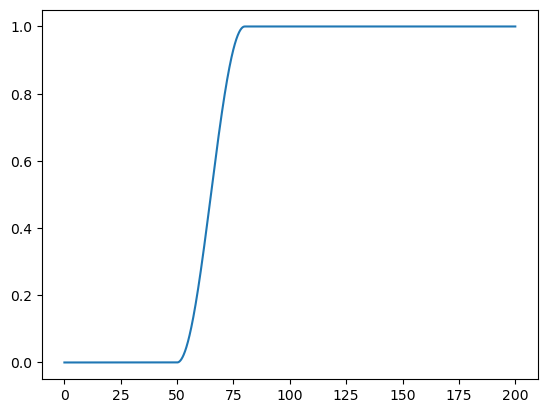

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f8d4284a6f0>

In [18]:
#ts = 0.0:0.1:50
stepp(t;ti=30) =t < 0.0 ? 0.0 : (t < ti ? sin((pi/2)*t/ti)^2 : 1)
ts=0.0:0.1:200
plt.plot(ts,stepp.(ts.-50;ti=30))

#plt.plot(ts,stepp.(ts))

In [19]:
#p.H0_ab


### Initial conditions

In [20]:
# eachindex(sys.dipoles)
# sys.dipoles
#typeof(sys.dipoles[:,:,1,1])#[3]
for I in eachindex(sys.dipoles)
    sys.dipoles[I] = Sunny.SVector(0.0, 0.0, 1.0)  
end

In [52]:
#### The idea is to modify the magnetic 
#sys.dipoles
sys.dipoles

3×2×1×1 Array{SVector{3, Float64}, 4}:
[:, :, 1, 1] =
 [0.0, 0.0, 1.0]  [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]  [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]  [0.0, 0.0, 1.0]

In [54]:
length(sys.dipoles[:,:,1,1])

6

### Plotting the initial configuration

In [29]:
# using Pkg
# Pkg.build("FFMPEG_jll")
# Pkg.instantiate()

In [43]:
using GLMakie
#using WGLMakie          # backend web
#WGLMakie.activate!()    # activar este backend para Makie

In [45]:
fig = GLMakie.Figure(size = (800, 600))
ax  = GLMakie.Axis3(fig[1, 1])
hidedecorations!(ax, grid = true)    # quita ticks, labels, etc.
hidespines!(ax)         # quita el cubo/bordes
# 3. Ajusta la cámara del Axis3: x → derecha, z ↑
ax.azimuth[]   = 0.3pi/2           # 0°
ax.elevation[] = 0.08pi          # 30°
Sunny.plot_spins!(
    ax, sys;
    color     = [S[3] for S in sys.dipoles] , arrowscale=0.3,show_cell=false,ndims=2, stemcolor=:lightgray
)
# --- fijar límites constantes ---
N = size(sys.dipoles, 1)          # asumiendo dims = (N,1,1,1)
fixed_limits = ((-1,  5+1.0),   # x
                (-2.2, 4.1),      # y
                (-0.9, 0.9))      # z

ax.limits[] = fixed_limits
fig   

┌ Warning:     GLFW couldn't create an OpenGL window.
│     This likely means, you don't have an OpenGL capable Graphic Card,
│     or you don't have an OpenGL 3.3 capable video driver installed.
│     Have a look at the troubleshooting section in the GLMakie readme:
│     https://github.com/MakieOrg/Makie.jl/tree/master/GLMakie#troubleshooting-opengl.
└ @ GLMakie ~/.julia/packages/GLMakie/1dQSN/src/screen.jl:291
┌ Warning:     GLFW couldn't create an OpenGL window.
│     This likely means, you don't have an OpenGL capable Graphic Card,
│     or you don't have an OpenGL 3.3 capable video driver installed.
│     Have a look at the troubleshooting section in the GLMakie readme:
│     https://github.com/MakieOrg/Makie.jl/tree/master/GLMakie#troubleshooting-opengl.
└ @ GLMakie ~/.julia/packages/GLMakie/1dQSN/src/screen.jl:291


### Integrator for Semiclassical dynamics

In [35]:
# dt     = 0.0001
# nsteps = 50000
# integ  = Langevin(0.1; damping=1.5, kT=1e-8)
#dt   = 0.01
#integ = Sunny.ImplicitMidpoint(dt; damping=1.0, kT=0.0)

### 3 projects in parallel
#1) Ladder batista sun
#2) siwtch on AFM with pulses
#3) introduce magnetic lead

In [61]:
duu = pointer(p.u,p)
typeof(duu.Ω_nλ1α_nλ1α)

Base.ReshapedArray{ComplexF64, 6, SubArray{ComplexF64, 1, Vector{ComplexF64}, Tuple{UnitRange{Int64}}, true}, Tuple{}}

## Evolution

In [36]:
#### Checking the measurement of observables 

function iter(t_0::Float64, Δt::Float64 ,t_end::Float64)
    ### Initiallize the state 
    sys.dipoles .= mags2
    println("Join the Main function")
    ### Setting the integrator for electrons
    prob       =  ODEProblem(eom!,uf2, (t_0,t_end), p )
    intg       =  init(prob,Vern7(),dt = Δt, save_everystep=false,adaptive=true,dense=false)#, reltol=1e-6, abstol=1e-8)#, verbose= true)
    ### Setting the integrator for classical spins
    integ      = Langevin(Δt ; damping=0.1, kT=0.0) 
    ### note the time step is much smaller because the units of the model are in meV
    ## and the electrons are in eV
    println("The integrator has been setted")
    ### ranges to calculate the observables 
    site_ranges = [get_sub(i, p.N_loc) for i in 1:p.N_sites]
    N_steps      = Int(round((t_end - t_0)/Δt))
    
    obs = ObservablesTDNEGF(p; N_tmax=N_steps , N_leads = p.Nα)
    @time for (i,t) in enumerate(t_0:Δt:(t_end-Δt))
        println("time: ", round(i*Δt,digits=2))
        flush(stdout)
        DifferentialEquations.step!(intg, Δt, true)
        Sunny.step!(sys,integ)
        ### with this pointer all the elements are going to be calculated
        dv =  pointer(intg.u ,p)  

        #### Observables
        obs_n_i!(dv, p, obs, intg.t, site_ranges)    ### Charge density
        obs_σ_i!(dv, p, obs, site_ranges)            ### Spin density 
        obs_Ixα!(p, obs, site_ranges)                ### Spin and charge current
        
        p.Δ_α .= [stepp(t-100;ti=10)*0.25 , -stepp(t-100;ti=10)*0.25] #*stepp(t;ti=30)stepp(t-100;ti=10)*0.5
        #obs_s_i!(sys.dipoles[:,:,1,1], p, obs)       ### Clasical spin density
        ### update parameters
        it = obs.idx
        update_H_s!(p.Nx,p.Ny,sys,obs.σx_i[:,:,it], 0.2) ### Update the Hamiltonian  ofclassical dynamics
        update_H_e!(p, site_ranges, sys.dipoles[:,:,1,1], 0.2)  ### Update the Hamiltonian electron dynamics 
    end
   # u_final = copy(intg.u)   # Copy of the final state
    return obs,sys.dipoles,intg.u
end

iter (generic function with 1 method)

In [35]:
obs2,mags2,uf2 = iter(0.0,0.1,50.0)

Join the Main function
The integrator has been setted
time: 0.1
time: 0.2
time: 0.3
time: 0.4
time: 0.5
time: 0.6
time: 0.7
time: 0.8
time: 0.9
time: 1.0
time: 1.1
time: 1.2
time: 1.3
time: 1.4
time: 1.5
time: 1.6
time: 1.7
time: 1.8
time: 1.9
time: 2.0
time: 2.1
time: 2.2
time: 2.3
time: 2.4
time: 2.5
time: 2.6
time: 2.7
time: 2.8
time: 2.9
time: 3.0
time: 3.1
time: 3.2
time: 3.3
time: 3.4
time: 3.5
time: 3.6
time: 3.7
time: 3.8
time: 3.9
time: 4.0
time: 4.1
time: 4.2
time: 4.3
time: 4.4
time: 4.5
time: 4.6
time: 4.7
time: 4.8
time: 4.9
time: 5.0
time: 5.1
time: 5.2
time: 5.3
time: 5.4
time: 5.5
time: 5.6
time: 5.7
time: 5.8
time: 5.9
time: 6.0
time: 6.1
time: 6.2
time: 6.3
time: 6.4
time: 6.5
time: 6.6
time: 6.7
time: 6.8
time: 6.9
time: 7.0
time: 7.1
time: 7.2
time: 7.3
time: 7.4
time: 7.5
time: 7.6
time: 7.7
time: 7.8
time: 7.9
time: 8.0
time: 8.1
time: 8.2
time: 8.3
time: 8.4
time: 8.5
time: 8.6
time: 8.7
time: 8.8
time: 8.9
time: 9.0
time: 9.1
time: 9.2
time: 9.3
time: 9.4
time: 

(ObservablesTDNEGF{Float64}([0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999  …  49.10000000000043, 49.20000000000043, 49.30000000000043, 49.40000000000043, 49.50000000000043, 49.600000000000435, 49.700000000000436, 49.80000000000044, 49.90000000000044, 50.00000000000044], [0.00991497781570887 0.03865740372841421 … 0.917811224186654 0.9179012690158717; 0.009914977815708891 0.038657384077405835 … 0.9164420161202924 0.9166918397037441; … ; 0.00991497781570887 0.038657384077405835 … 0.9164420161202924 0.9166918397037442; 0.00991497781570889 0.03865740372841421 … 0.9178112241866541 0.9179012690158717], [0.00030009842436751893 -1.5708685270288053e-10 -2.489215987491397e-7; -0.00030009842436751893 -1.5708685267559135e-10 2.4892159874653763e-7; … ; 0.00030009842436751893 1.5708685272390739e-10 2.489215987491397e-7; -0.00030009842436751893 1.5708685269133382e-10 -2.489215987448029e-7;;; 0.002302479049667683 -4.565706803667156e-5 7.1

In [37]:
obs3,mags3,uf3 = iter(0.0,0.1,50.0)

Join the Main function
The integrator has been setted
time: 0.1
time: 0.2
time: 0.3
time: 0.4
time: 0.5
time: 0.6
time: 0.7
time: 0.8
time: 0.9
time: 1.0
time: 1.1
time: 1.2
time: 1.3
time: 1.4
time: 1.5
time: 1.6
time: 1.7
time: 1.8
time: 1.9
time: 2.0
time: 2.1
time: 2.2
time: 2.3
time: 2.4
time: 2.5
time: 2.6
time: 2.7
time: 2.8
time: 2.9
time: 3.0
time: 3.1
time: 3.2
time: 3.3
time: 3.4
time: 3.5
time: 3.6
time: 3.7
time: 3.8
time: 3.9
time: 4.0
time: 4.1
time: 4.2
time: 4.3
time: 4.4
time: 4.5
time: 4.6
time: 4.7
time: 4.8
time: 4.9
time: 5.0
time: 5.1
time: 5.2
time: 5.3
time: 5.4
time: 5.5
time: 5.6
time: 5.7
time: 5.8
time: 5.9
time: 6.0
time: 6.1
time: 6.2
time: 6.3
time: 6.4
time: 6.5
time: 6.6
time: 6.7
time: 6.8
time: 6.9
time: 7.0
time: 7.1
time: 7.2
time: 7.3
time: 7.4
time: 7.5
time: 7.6
time: 7.7
time: 7.8
time: 7.9
time: 8.0
time: 8.1
time: 8.2
time: 8.3
time: 8.4
time: 8.5
time: 8.6
time: 8.7
time: 8.8
time: 8.9
time: 9.0
time: 9.1
time: 9.2
time: 9.3
time: 9.4
time: 

(ObservablesTDNEGF{Float64}([0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999  …  49.10000000000043, 49.20000000000043, 49.30000000000043, 49.40000000000043, 49.50000000000043, 49.600000000000435, 49.700000000000436, 49.80000000000044, 49.90000000000044, 50.00000000000044], [0.9179111872350065 0.9178434078524884 … 0.9183306421935749 0.9183324076780186; 0.9169216679817145 0.9170935291628879 … 0.9187111760440143 0.9187177194379359; … ; 0.9169216679817145 0.9170935291628878 … 0.9187111760440145 0.9187177194379361; 0.9179111872350065 0.9178434078524884 … 0.9183306421935749 0.9183324076780186], [0.07684908835786589 0.042992344004809294 0.02780238865175194; 0.08461990314522216 0.019838624043079716 0.02415129754571549; … ; -0.08461990314522225 -0.01983862404307974 0.024151297545715544; -0.07684908835786594 -0.042992344004809245 0.027802388651752108;;; 0.0772600357917136 0.04223195310213009 0.028020905442967925; 0.08440855701631844 0

In [47]:
####### TO DO 
#1) Check with otther algorithm
#2) Use zandpack initial configuration 
#3) Local spin currents when rashba?
#4) Check the whole velocity and memory...
#5) SAve state  <- Checked the system can store the final state
#6) Increase damping to Gs and later use it 
# mags and ufs are the thermal states 

In [39]:
1636*2/3/60

18.17777777777778

## Figures

In [39]:
using PyPlot
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text
fs=25

25

In [40]:
#p.H_ab

In [41]:
#0.1
##Units are I/ V = 2e/h = 4pi e/(hbar) ->hbar=1,e=1 ->4

#hbar = h/2pi ->
#obs2=obs

### Charge Current

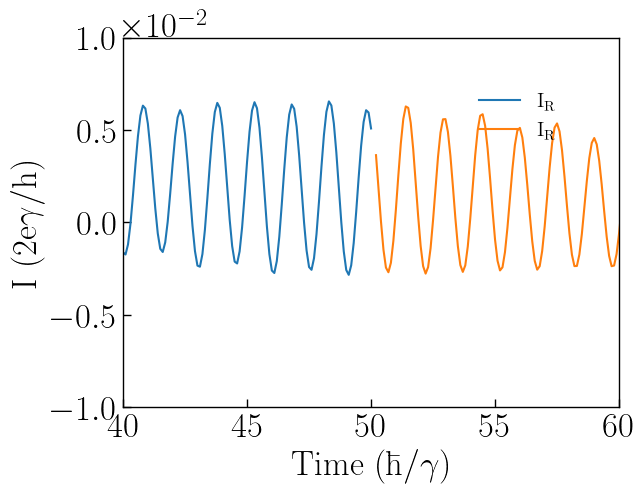

(40.0, 60.0)

In [48]:
fig,axs = plt.subplots(1,1)
axs.plot(obs2.t,obs2.Iα[1,:]*pi, label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
axs.plot(obs2.t[end] +0.1 .+ obs3.t,obs3.Iα[1,:]*pi, label = raw"$\mathrm{I_R}$") 
#axs.plot(obs.t,obs.Iα[2,:]*pi, label = raw"$\mathrm{I_L}$")
#axs.plot(obs.t,obs.Iα[2,:]*pi .+ obs.Iα[1,:]*pi , label = raw"$\mathrm{I_T}$")


# axs.plot(obs2.t .+obs.t[end],obs2.Iα[1,:]*pi, label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
# axs.plot(obs2.t .+obs.t[end],obs2.Iα[2,:]*pi, label = raw"$\mathrm{I_L}$")
#axs.plot(obs2.t .+obs.t[end],obs2.Iα[2,:]*pi .+ obs.Iα[1,:]*pi , label = raw"$\mathrm{I_T}$")
#axs.axhline(1)
#axs.axhline(-0.1)

axs.set_ylabel(L"$\mathrm{I\ (2e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))
plt.ylim(-1e-2,1e-2)
plt.xlim(40,60)

In [151]:
#pi/2
obs.Iαx[1,2,:]

5000-element Vector{Float64}:
  2.2488620086144953e-10
 -1.1211882652763933e-9
 -9.225318587388967e-9
  8.362559283611216e-9
  7.718567282500796e-8
  4.9911357856164545e-8
 -2.0008684866236763e-7
 -3.093242218902073e-7
  1.6957943458858517e-7
  7.335685672379359e-7
  3.228034578218412e-7
 -8.619948700649147e-7
 -1.1211292515624473e-6
  ⋮
 -0.015675377084181673
 -0.015663884454504756
 -0.015652392758462825
 -0.015640902017681972
 -0.015629412253911946
 -0.015617923489049442
 -0.01560643574511138
 -0.015594949044248203
 -0.015583463408751578
 -0.015571978861042227
 -0.015560495423682577
 -0.015549013271136825

In [152]:
#4/3
#obs.Iαx[1,1,:]

### Spin Current

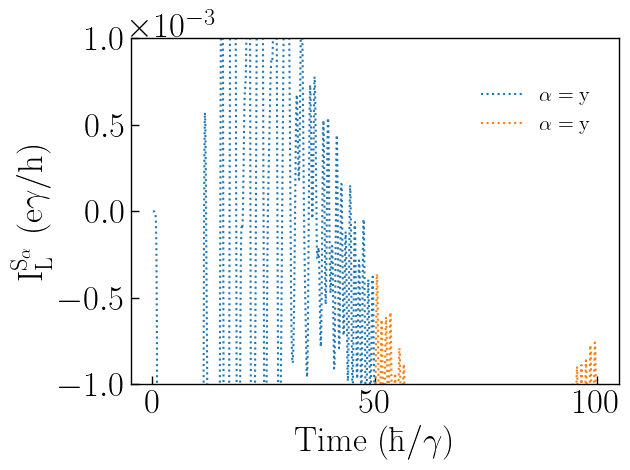

In [53]:
fig,axs = plt.subplots(1,1)
# axs.plot(obs.t,obs.Iαx[1,1,:], label = raw"$\mathrm{\alpha = x}$")
# axs.plot(obs.t,obs.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
# axs.plot(obs.t,obs.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")

axs.plot(obs2.t,obs2.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
axs.plot(obs2.t[end] .+  obs3.t, obs3.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")

# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,1,:], label = raw"$\mathrm{\alpha = x}$")
# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")

#axs.plot(obs.t,obs.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")

#axs.plot(obs.t,obs.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
axs.set_ylabel(raw"$\mathrm{I^{S_{\alpha}}_L\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.axhline(0.08)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))
axs.set_ylim(-0.001,0.001)
#plt.xlim(0,200)
plt.tight_layout()


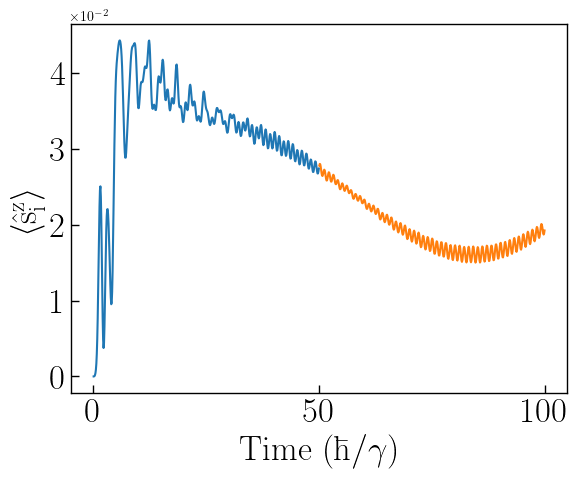

PyObject Text(0.5, 44.59250034592501, '$\\mathrm{Time\\ (\\hbar/\\gamma)}$')

In [54]:
fig,axs =  plt.subplots(1,1)

axs.plot(obs2.t,obs2.σx_i[1,3,:],label= "Neq site=1")
axs.plot(obs2.t[end] .+obs3.t ,obs3.σx_i[1,3,:],label= "Neq site=1")

axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)

axs.set_ylabel(raw"$\langle\mathrm{\hat{s}^{z}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)

### Charge density

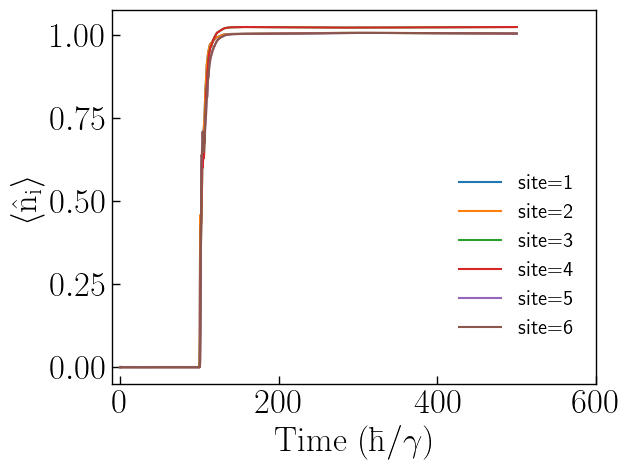

In [154]:
fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,6)
for site in sites
    axs.plot(obs.t,obs.n_i[site,:],label= "site=$(site)")#,alpha =1-0.2*i ) ### Charge bound current
end

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
plt.xlim(-10,600)
plt.tight_layout()
#axs.set_ylim(1-0.1,1+0.1)
#axs.set_ylim(0.0,2.0)

In [155]:
#obs.n_i[:,end]

In [156]:
#p.H_ab[2:4,2:4]

#p.H0_ab


### Spin density 

In [67]:
1/33

0.030303030303030304

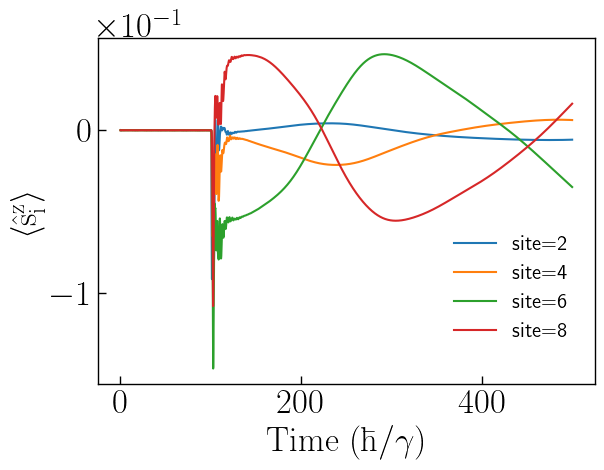

In [157]:


fig,axs =  plt.subplots(1,1)
site = 1
sites = 2:2:8#range(1,4)
for site in sites
    
    #axs.plot(obs2.t,obs2.σx_i[site,1,:],label= "site=$(site)")#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(obs.t,obs.σx_i[site,2,:],label= raw"$\alpha=y$ ")
    axs.plot(obs.t,obs.σx_i[site,1,:],label= "site=$(site)")
    #axs.plot(obs2.t .+obs.t[end],obs2.σx_i[site,3,:],label= raw"$\alpha=z$ ")
end

axs.set_ylabel(raw"$\langle\mathrm{\hat{s}^{z}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(200,300)
plt.tight_layout()
#plt.ylim(-1e-2,1e-2)

#plt.ylim(-5e-3,5e-3)

### Classical spin density 

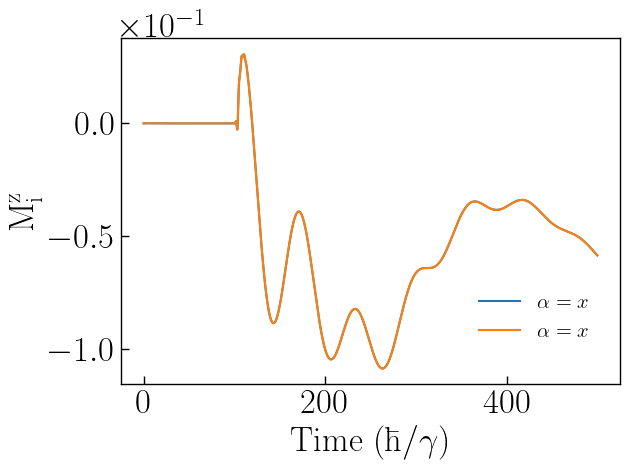

In [158]:

fig,axs =  plt.subplots(1,1)
site = 3
sites = range(1,2)
for site in sites
   # obs2.t .+obs.t[end]
    axs.plot(obs.t,obs.sx_i[site,2,:],label= raw"$\alpha=x$ ")#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(obs.t,obs.sx_i[site,2,:],label= raw"$\alpha=y$ ")
    #axs.plot(obs.t,obs.sx_i[site,3,:],label= "site=$(site)")
   # axs.plot(obs2.t .+obs.t[end],obs2.sx_i[site,3,:],label= raw"$\alpha=z$ ")
end

axs.set_ylabel(raw"$\mathrm{M^{z}_i}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(0,1000)
plt.tight_layout()

### Figure: results

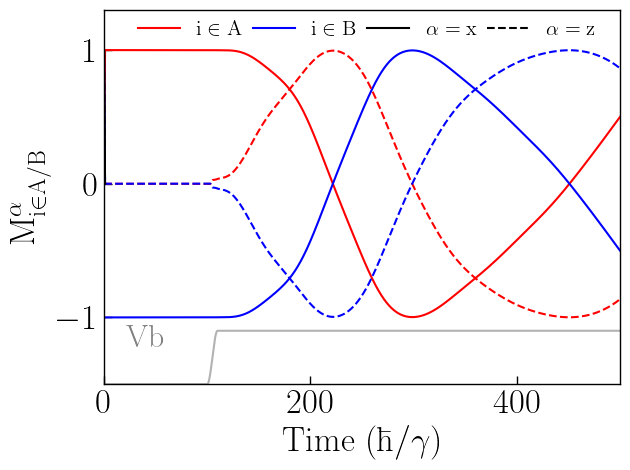

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f808cb60800>

In [160]:

fig,axs =  plt.subplots(1,1)
site = 3
sites = range(1,2)
# for site in sites
#    # obs2.t .+obs.t[end]
#     axs.plot(obs.t,obs.sx_i[site,1,:])#,alpha =1-0.2*i ) ### Charge bound current
#     #axs.plot(obs.t,obs.sx_i[site,2,:],label= raw"$\alpha=y$ ")
#     #axs.plot(obs.t,obs.sx_i[site,3,:],label= "site=$(site)")
#    # axs.plot(obs2.t .+obs.t[end],obs2.sx_i[site,3,:],label= raw"$\alpha=z$ ")
# end
axs.plot(obs.t,obs.sx_i[1,1,:],color = "red")
axs.plot(obs.t,obs.sx_i[2,1,:],color = "blue")

axs.plot(obs.t,obs.sx_i[1,3,:],color = "red",ls = "--")
axs.plot(obs.t,obs.sx_i[2,3,:],color = "blue",ls = "--")

line1 = plt.plot([0, 1], [0, 1], color="red",ls="-")[1]
line2 = plt.plot([0, 1], [1, 0], color="blue",ls="-")[1]
line3 = plt.plot([0, 1], [1, 0], color="black",ls="-")[1]
line4 = plt.plot([0, 1], [1, 0], color="black",ls="--")[1]
lg2 = axs.legend([line1, line2, line3, line4], [raw"$\rm{i \in A}$", raw"$\rm{i \in B}$", raw"$\rm{\alpha=x}$", raw"$\rm{\alpha=z}$"]
                ,frameon = false, fontsize = fs-10, loc= (0.05,  0.9),ncol =4,columnspacing=0.5)
axs.add_artist(lg2)

axs.set_ylabel(raw"$\mathrm{M^{\alpha}_{i \in A/B}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
axs.text(x=0.08, y=0.1, s = raw"$\mathrm{Vb}$",fontsize=fs-2,ha="center", transform=axs.transAxes,color="gray")
plt.xlim(0,500)
plt.ylim(-1.5,1.3)
plt.tight_layout()
ts = 0.0:0.1:800 
plt.plot(ts,stepp.(ts.-100;ti=10)*0.4 .- 1.5,color = "gray",alpha = 0.6)

### Interactive Classical magnetization

In [85]:
mags

3×2×1×1 Array{SVector{3, Float64}, 4}:
[:, :, 1, 1] =
 [-0.156418, -0.069818, 0.98522]    [-0.158444, -0.0379144, 0.98664]
 [-0.286678, -0.0949916, 0.953306]  [-0.293016, -0.0127669, 0.956022]
 [-0.393076, -0.0663875, 0.917106]  [-0.398385, -0.037952, 0.916433]

In [86]:
mags2

3×2×1×1 Array{SVector{3, Float64}, 4}:
[:, :, 1, 1] =
 [-0.156418, -0.069818, 0.98522]    [-0.158444, -0.0379144, 0.98664]
 [-0.286678, -0.0949916, 0.953306]  [-0.293016, -0.0127669, 0.956022]
 [-0.393076, -0.0663875, 0.917106]  [-0.398385, -0.037952, 0.916433]

In [293]:
sys.dipoles[1]

3-element SVector{3, Float64} with indices SOneTo(3):
 -0.5926197634550648
 -0.1796058023285761
  0.7852028857132222

In [89]:
sys.dipoles .= mags2

3×2×1×1 Array{SVector{3, Float64}, 4}:
[:, :, 1, 1] =
 [-0.156418, -0.069818, 0.98522]    [-0.158444, -0.0379144, 0.98664]
 [-0.286678, -0.0949916, 0.953306]  [-0.293016, -0.0127669, 0.956022]
 [-0.393076, -0.0663875, 0.917106]  [-0.398385, -0.037952, 0.916433]

In [91]:
fig = GLMakie.Figure(size = (800, 600))
ax  = GLMakie.Axis3(fig[1, 1])
hidedecorations!(ax, grid = true)    # quita ticks, labels, etc.
hidespines!(ax)         # quita el cubo/bordes
# 3. Ajusta la cámara del Axis3: x → derecha, z ↑
ax.azimuth[]   = 0.3pi/2           # 0°
ax.elevation[] = 0.08pi          # 30°
Sunny.plot_spins!(
    ax, sys;
    color     = [S[3] for S in sys.dipoles], arrowscale=0.6,show_cell=false,ndims=2, stemcolor=:lightgray,
)
# --- fijar límites constantes ---
N = size(sys.dipoles, 1)          # asumiendo dims = (N,1,1,1)
# fixed_limits = ((-1,  5+1.0),   # x
#                 (-2.2, 4.1),      # y
#                 (-0.9, 0.9))      # z

# ax.limits[] = fixed_limits
fig   

## Example 1: Time dependent voltage and electrons with SOC

#### 6x2 Configuration 

##### Initial parameters



In [140]:
####Note that we can initiallize the system only with the dimension of the system 
Ny, Nσ, N_orb, N_λ1, N_λ2, β = 2,2,1, 49, 20, 33.0
p = ModelParamsTDNEGF(Nx   = 6, Ny   = Ny,  Nσ   = Nσ, N_orb = N_orb, #### dimension
                      Nα   = 2,  N_λ1 = N_λ1, N_λ2 = N_λ2 ) ;
### Now we can assign the real initial values 

H_ab    = build_H_ab(;Nx = p.Nx,Ny = p.Ny, Nσ = p.Nσ, N_orb = p.N_orb, γ = 1.0,γso = 0.5)
Σᴸ_nλ   = build_Σᴸ_nλ(Rλ, zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β) ;
Σᴳ_nλ   = build_Σᴳ_nλ(Rλ, zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β) ;
χ_nλ    = build_χ_nλ(zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β)
ξ_anR   = build_ξ_an(p.Nx, p.Ny, p.Nσ, p.N_orb; xcol = p.Nx,y_coup = 1:p.Ny)
ξ_anL   = build_ξ_an(p.Nx, p.Ny, p.Nσ, p.N_orb; xcol = 1,y_coup = 1:p.Ny)
#### Asigning initial values of the precalculated things
p.H_ab             .= H_ab
p.H0_ab            .= H_ab
p.Δ_α              .= [0.0,0.0] 
#### Self energies
p.Σᴸ_nλα[:,:,1]    .= Σᴸ_nλ
p.Σᴸ_nλα[:,:,2]    .= Σᴸ_nλ
p.Σᴳ_nλα[:,:,1]    .= Σᴳ_nλ
p.Σᴳ_nλα[:,:,2]    .= Σᴳ_nλ
Γ_nλα = 1im*copy(p.Σᴳ_nλα - p.Σᴸ_nλα)
p.Γ_nλα    .= Γ_nλα
#1im*(p.Σᴳ_nλα - p.Σᴸ_nλα)

#### Exponent from poles in the residue theorem 
p.χ_nλα[:,:,1]     .= χ_nλ
p.χ_nλα[:,:,2]     .= χ_nλ
#### Channel vectors 
p.ξ_anα[:,:,1]     .= ξ_anL
p.ξ_anα[:,:,2]     .= ξ_anR;
####
p.χ′_nλα  .= conj.(p.χ_nλα)
p.Σᴸ′_nλα .= conj.(p.Σᴸ_nλα)
p.Γ′_nλα  .= conj.(p.Γ_nλα);


In [141]:

#CartesianIndex.(rows, cols)
#tuple.([(1,1), (2,2), (5,5), (6,6) ])
#p.H_ab[CartesianIndex.([(1,1), (2,2), (3,3) ,(4,4)  ,  ])]
#### Setting the Barrier


In [142]:
u = Units(:meV, :angstrom)

#### Conversion to eV
e_0 = 1e-3
T_unit = u.T/e_0

#########3 Instead I am working in eV
a = 1.0
latvecs   = lattice_vectors(a, a, 2*a, 90, 90, 90)  # cúbica
positions = [[0.5, 0.5, 0.0]]                    # 1 átomo por celda
cryst = Crystal(latvecs, positions)
moments = [1 => Moment(s=1.0, g=2.0)]
# --- Construir una cadena 1D de N sitios ---
Nx = p.Nx
Ny = p.Ny
sys = System(cryst, moments, :dipole; dims=(2, Ny, 1)) ### 2D problem 
# Todos los spins arrancan en +z automáticamente:
#   "All spins are initially polarized in the global z-direction." 
# --- Interacción: Heisenberg 1D con vecino más cercano en x ---
J = 0.05#20 *e_0 ### thi is in eV and is equivalent to 1 meV (- is ferro)
set_exchange!(sys, J, Bond(1, 1, [1, 0, 0]))  # vecino +x
set_exchange!(sys, J, Bond(1, 1, [0, 1, 0]))  # vecino +y
# bondy = Bond(1, 1, [0, 1, 0])         # sitio 1 a sitio 1 en la celda siguiente en x
# set_exchange!(sys, J, bondy)
# --- Campo magnético transversal en x (Sx) ---
# Bx_T = 1.0 * e_0 # T_unit     # 2 Tesla por ejemplo
# set_field!(sys, [Bx_T, 0.0, 0.0])  # campo homogéneo en x
# Remove periodic boundaries along the 1st and 3rd dimensions
sys = to_inhomogeneous(sys)
remove_periodicity!(sys, (true, true, true))

In [143]:

for I in eachindex(sys.dipoles)
    println(I)
    sys.dipoles[I] = Sunny.SVector((-1)^(I), 0.0, 0.0)  
end

1
2
3
4


In [144]:
#eachindex(sys.dipoles)
#sys.dipoles[4]

In [145]:
#p.H_ab
sys.dipoles[1,1,1,1] = Sunny.SVector( 1.0, 0.0, 0.0) 
sys.dipoles[1,2,1,1] = Sunny.SVector( -1.0, 0.0, 0.0) 
sys.dipoles[2,1,1,1] = Sunny.SVector( -1.0, 0.0, 0.0) 
sys.dipoles[2,2,1,1] = Sunny.SVector( 1.0, 0.0, 0.0) 

3-element SVector{3, Float64} with indices SOneTo(3):
 1.0
 0.0
 0.0

In [146]:
sys.dipoles

2×2×1×1 Array{SVector{3, Float64}, 4}:
[:, :, 1, 1] =
 [1.0, 0.0, 0.0]   [-1.0, 0.0, 0.0]
 [-1.0, 0.0, 0.0]  [1.0, 0.0, 0.0]

#### Evolution

In [147]:
function iter_example_1(t_0::Float64, Δt::Float64 ,t_end::Float64)
    ### Initiallize the state 
    println("Join the Main function")
    ### Setting the integrator for electrons
    prob       =  ODEProblem(eom!,p.u, (t_0,t_end), p )
    intg       =  init(prob,Vern7(),dt = Δt, save_everystep=false,adaptive=true,dense=false)#, reltol=1e-6, abstol=1e-8)#, verbose= true)
    integ      = Langevin(Δt ; damping=0.1, kT=0.0) 
    ### Setting the integrator for classical spins
    #integ      = Langevin(Δt ; damping=0.1, kT=0.0) 
    ### note the time step is much smaller because the units of the model are in meV
    ## and the electrons are in eV
    println("The integrator has been setted")
    ### ranges to calculate the observables 
    site_ranges = [get_sub(i, p.N_loc) for i in 1:p.N_sites]
    site_ranges_couple = [get_sub(i, p.N_loc) for i in [5,6,7,8]]
    N_steps      = Int(round((t_end - t_0)/Δt))
    obs = ObservablesTDNEGF(p; N_tmax=N_steps , N_leads = p.Nα)
    ### Setting the initial Barrier
    for i in [1,2,3,4, 9,10,11,12]
        p.H0_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*50
        p.H_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*50
    end
    #update_H_e!(p, site_ranges_couple, sys.dipoles[:,:,1,1], 0.2) 
    
    @time for (i,t) in enumerate(t_0:Δt:(t_end-Δt))
        println("time: ", round(i*Δt,digits=2))
        flush(stdout)
        DifferentialEquations.step!(intg, Δt, true)
        Sunny.step!(sys,integ)
        ### with this pointer all the elements are going to be calculated
        dv =  pointer(intg.u ,p)  
        #### Observables
        obs_n_i!(dv, p, obs, intg.t, site_ranges)    ### Charge density
        obs_σ_i!(dv, p, obs, site_ranges)            ### Spin density 
        obs_Ixα!(p, obs, site_ranges)                ### Spin and charge current
        
        obs_s_i!(sys.dipoles[:,:,1,1], p, obs, [1,2,3,4])       ### Clasical spin density
        #println(0)
        p.Δ_α .= [stepp(t-10;ti=30)*0.5 , -stepp(t-10;ti=30)*0.5] #*stepp(t;ti=30)stepp(t-100;ti=10)*0.5
        
        ### update parameters
        if t ≈ 100.0 # Turn off the bias
            println("pass")
            for i in [1,2,3,4, 9,10,11,12]
                p.H0_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*0.0
                p.H_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*0.0
            end
        end
        
        
        it = obs.idx
        update_H_s!(2,p.Ny,sys,obs.σx_i[:,:,it], 0.1) ### Update the Hamiltonian  ofclassical dynamics
        update_H_e!(p, site_ranges_couple, sys.dipoles[:,:,1,1], 0.1)  ### Update the Hamiltonian electron dynamics 
       ## 0.5 for decoupled and good results 
    end
    return obs, intg.u
end

iter_example_1 (generic function with 1 method)

In [148]:
obs, uf2 = iter_example_1(0.0,0.1,500.0)

Join the Main function
The integrator has been setted
time: 0.1
time: 0.2
time: 0.3
time: 0.4
time: 0.5
time: 0.6
time: 0.7
time: 0.8
time: 0.9
time: 1.0
time: 1.1
time: 1.2
time: 1.3
time: 1.4
time: 1.5
time: 1.6
time: 1.7
time: 1.8
time: 1.9
time: 2.0
time: 2.1
time: 2.2
time: 2.3
time: 2.4
time: 2.5
time: 2.6
time: 2.7
time: 2.8
time: 2.9
time: 3.0
time: 3.1
time: 3.2
time: 3.3
time: 3.4
time: 3.5
time: 3.6
time: 3.7
time: 3.8
time: 3.9
time: 4.0
time: 4.1
time: 4.2
time: 4.3
time: 4.4
time: 4.5
time: 4.6
time: 4.7
time: 4.8
time: 4.9
time: 5.0
time: 5.1
time: 5.2
time: 5.3
time: 5.4
time: 5.5
time: 5.6
time: 5.7
time: 5.8
time: 5.9
time: 6.0
time: 6.1
time: 6.2
time: 6.3
time: 6.4
time: 6.5
time: 6.6
time: 6.7
time: 6.8
time: 6.9
time: 7.0
time: 7.1
time: 7.2
time: 7.3
time: 7.4
time: 7.5
time: 7.6
time: 7.7
time: 7.8
time: 7.9
time: 8.0
time: 8.1
time: 8.2
time: 8.3
time: 8.4
time: 8.5
time: 8.6
time: 8.7
time: 8.8
time: 8.9
time: 9.0
time: 9.1
time: 9.2
time: 9.3
time: 9.4
time: 

(ObservablesTDNEGF{Float64}([0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999  …  499.100000000045, 499.200000000045, 499.30000000004503, 499.40000000004505, 499.5000000000451, 499.6000000000451, 499.7000000000451, 499.80000000004515, 499.90000000004517, 500.0000000000452], [0.0005226896141973386 0.0013470793865939924 … 1.0032758633905257 1.0032747209552384; 0.0005226896141973525 0.001347079386593997 … 1.0032758633905465 1.0032747209552593; … ; 0.0005226896141973382 0.0013470793861698714 … 0.9956276859033143 0.99562610775702; 0.0005226896141973527 0.0013470793861698797 … 0.9956276859032789 0.9956261077569845], [1.2528575212960006e-5 -1.8234174663562158e-9 7.947945857174604e-9; -1.2528575212959745e-5 -1.823417466384581e-9 -7.947945859451428e-9; … ; 1.2528575212960031e-5 1.8234174663210365e-9 -7.947945858584066e-9; -1.2528575212959793e-5 1.823417466282188e-9 7.947945859071957e-9;;; 6.914577244989999e-5 -7.485778904976883e-9 -3.

In [ ]:
###### The problem is in update He

## Test Beds

search: stepp step! step strip sleep setp stem mktemp stderr rstrip lstrip



No documentation found for private symbol.

`stepp` is a `Function`.

```
# 1 method for generic function "stepp" from Main:
 [1] stepp(t; ti)
     @ In[22]:2
```


In [108]:
using Tullio
### Computed integral over the exact self energy 
function selfenergy(ϵ; γ=1, γc=1.)# thop = thop, t_ls = 1.) 
    ### Note that this configuration for the self energy can be modified later
    #thop = global_var.thop
    Δ = 4 * γ^2 - ϵ^2
    if real(Δ) > 0
        Σ = ϵ - im * sqrt(Δ)
    else
        if real(ϵ) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ = ϵ - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2*γ^2)) #/2
    return Σ
end
function Gamma_ϵ(ϵ;γ=1,γc=1.)#
    -2*(imag(selfenergy(ϵ;γ=γ,γc=γc)) ) ###### The small factor can take into account bound state?
end

function SelfL(t;γ=1,γc=1., β=β)
    retval = 0.0+ 0.0im
    dϵ = 0.001
    ϵs = -3γ:dϵ:3γ
    Gamma = Gamma_ϵ.(ϵs;γ,γc)
    e = exp.(-1im*ϵs*t)
    #ep = -sqrt(4*γ^2+ 4*(j_sd)^2)*γc^2/(γ^2)
    f = fermi.(ϵs*β)
    @tullio retval = Gamma[α]*e[α]*f[α]
    retval = 1im*retval*dϵ/2pi
    #retval +=1im*fermi_mu(-ep)*exp.(-1im*ep*t)*sqrt(ep^2-4γ^2)/ep/(2pi)  #### Bound state
end

function SelfG(t;γ=1,γc=1., β=β)
    retval = 0.0
    dϵ = 0.01
    ϵs = -2γ:dϵ:2γ
    Gamma = Gamma_ϵ.(ϵs;γ,γc)
    e = exp.(-1im*ϵs*t)
    f = -fermi.(ϵs*β) .+ 1
    @tullio retval = Gamma[α]*e[α]*f[α]
    retval = -1im*retval*dϵ/2pi
end

SelfG (generic function with 1 method)

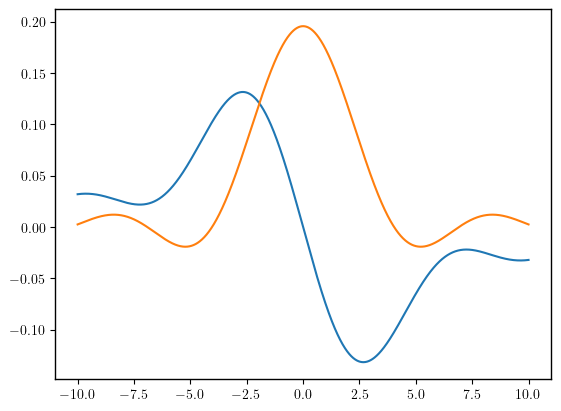

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe57cd30680>

In [109]:
#### CHecking the 1D case

#Rλ = [Rλ1;  Rλ2] ### This are the proper values for the residues and poles 
#zλ = [zλ1;  zλ2] ### if needed they can be modified tlater 

# Rλ1 = Rλ1*2pi ;
# Rλ2 =  -Rλ2 ### 

Rλ = [Rλ1;  Rλ2]
zλ = [zλ1;  zλ2]
Ny, Nσ, N_orb, Nλ1, Nλ2,β = 2,2,1, 49, 20, 33.0
Σᴸ_nλ_p = build_Σᴸ_nλ(Rλ, zλ, Ny, Nσ, N_orb, Nλ1, Nλ2; β=β) ;
χ_nλ_p    = build_χ_nλ(zλ, Ny, Nσ, N_orb, Nλ1, Nλ2; β=β)
# # ########
Σᴸ_nλ_m = -build_Σᴸ_nλ(conj(Rλ), conj(zλ), Ny, Nσ, N_orb, Nλ1, Nλ2; β=β) ;
χ_nλ_m    = build_χ_nλ(conj(zλ), conj(Ny), Nσ, N_orb, Nλ1, Nλ2; β=β)
# ### we can inmediatly check that the is not just to take the conjugate
# ### maybe we can relate easily the coefficients, but for the moment 
# ### lets take explicitly the positive an negative part 
# idx=1 
# # # ### Now; using this we can build the function in the time domain 
# Σᴸ11_p(t)    = sum(exp.(-1im*χ_nλ_p[idx,:]*t).*Σᴸ_nλ_p[idx,:])
# Σᴸ11_m(t)    = sum(exp.(-1im*χ_nλ_m[idx,:]*t).*Σᴸ_nλ_m[idx,:])
# Σᴸ11(t) = t >= 0.0 ? Σᴸ11_p(t) : Σᴸ11_m(t)
# #Σᴸ11(t) = t >= 0 ? Σᴸ11_p(t) : -conj(Σᴸ11_p(-t))
# ts = -10:0.01:10
# plt.plot(ts,real(Σᴸ11.(ts)))
# plt.plot(ts,imag(Σᴸ11.(ts)) )

plt.figure()
# plt.plot(ts,imag(SelfL.(ts, β=β)),ls="--")
# plt.plot(ts,real(Σᴸ11.(ts)) )
# plt.plot(ts,real(SelfL.(ts, β=β)),ls="--")
idx=4   ########### Is possible that the problem is in the evaluation of this elements for 2d case
Σᴸ33_p(t)    = sum(exp.(-1im*χ_nλ_p[idx,:]*t).*Σᴸ_nλ_p[idx,:])
Σᴸ33_m(t)    = sum(exp.(-1im*χ_nλ_m[idx,:]*t).*Σᴸ_nλ_m[idx,:])
Σᴸ33(t) = t >= 0.0 ? Σᴸ33_p(t) : Σᴸ33_m(t)
#Σᴸ33(t) = t >= 0 ? Σᴸ33_p(t) : -conj(Σᴸ33_p(-t))
ts = -10:0.001:10
plt.plot(ts,real(Σᴸ33.(ts)))
plt.plot(ts,imag(Σᴸ33.(ts)) )


In [110]:
ξ_anL   = build_ξ_an(1, 2, 2, 1; xcol = 1,y_coup = 1:2)

### Build the 2d matrix
Σᴸ33_p(t,n)    = sum(exp.(-1im*χ_nλ_p[n,:]*t).*Σᴸ_nλ_p[n,:])
Σᴸ33_m(t,n)    = sum(exp.(-1im*χ_nλ_m[n,:]*t).*Σᴸ_nλ_m[n,:])
Σᴸ33(t,n) = t >= 0.0 ? Σᴸ33_p(t,n) : Σᴸ33_m(t,n)
#Σᴸ33(t) = t >= 0 ? Σᴸ33_p(t) : -conj(Σᴸ33_p(-t))

ξ = ξ_anL
# Σdiag(t): Nc×Nc diagonal (pero ojo: tu Σ(t) 2×2 no coincide con Nc=4; ver nota abajo)
Σdiag(t) = Diagonal([Σᴸ33(t,1), Σᴸ33(t,2), Σᴸ33(t,3), Σᴸ33(t,4)  ])  # ejemplo si Nc=2

Σfull(t) = ξ' * Σdiag(t) * ξ   # Ns×Ns

suu(t,n) = Σfull(t)[n,n]

sab(t,n,m) = Σfull(t)[n,m]

sab (generic function with 1 method)

In [128]:
?build_ξ_an()

No documentation found for private symbol.

`build_ξ_an` is a `Function`.

```
# 1 method for generic function "build_ξ_an" from Main:
 [1] build_ξ_an(Nx::Int64, Ny::Int64, Nσ::Int64, N_orb::Int64; xcol, y_coup)
     @ In[107]:65
```


In [127]:
ξ_anL[:,1]

4-element Vector{ComplexF64}:
 0.7071067811865475 + 0.0im
                0.0 + 0.0im
 0.7071067811865476 + 0.0im
                0.0 + 0.0im

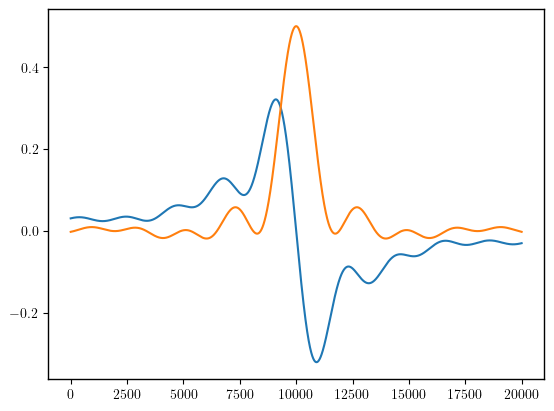

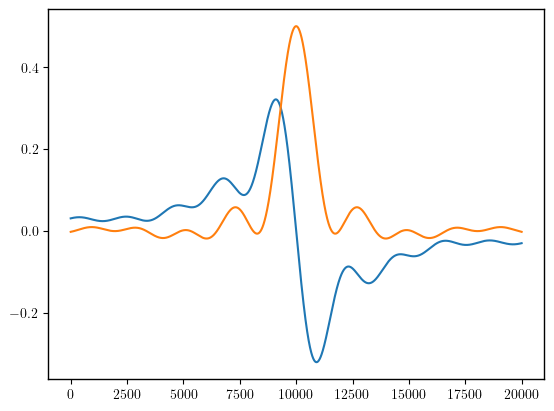

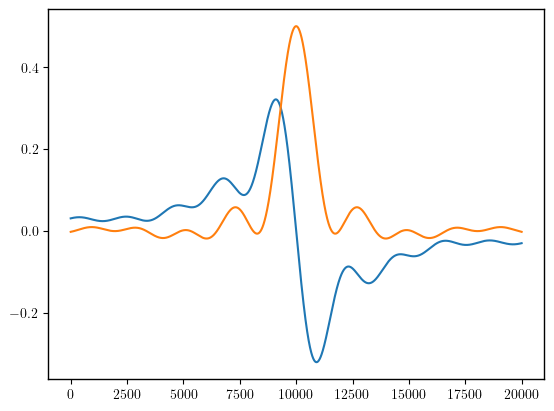

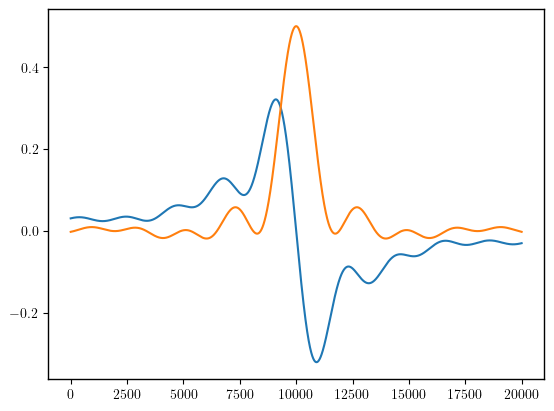

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe57cd9d5e0>

In [111]:
plt.plot(real(suu.(ts,1)))
plt.plot(imag(suu.(ts,1)))
plt.figure()
plt.plot(real(suu.(ts,2)))
plt.plot(imag(suu.(ts,2)))
plt.figure()
plt.plot(real(suu.(ts,3)))
plt.plot(imag(suu.(ts,3)))
plt.figure()
plt.plot(real(suu.(ts,4)))
plt.plot(imag(suu.(ts,4)))

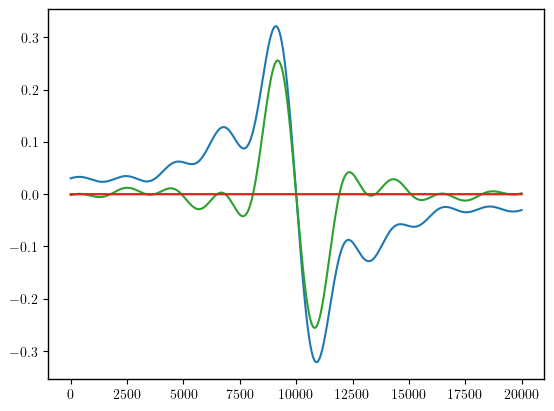

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe57ccc5130>

In [112]:
plt.plot(real(sab.(ts,1,1))) 
plt.plot(real(sab.(ts,1,2))) 
plt.plot(real(sab.(ts,1,3))) 
plt.plot(real(sab.(ts,1,4))) 

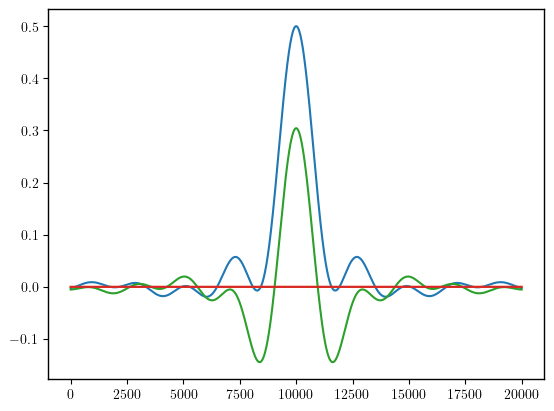

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe57cb4c8c0>

In [113]:
plt.plot(imag(sab.(ts,1,1))) 
plt.plot(imag(sab.(ts,1,2))) 
plt.plot(imag(sab.(ts,1,3))) 
plt.plot(imag(sab.(ts,1,4))) 

In [114]:
#ξ_anL[2,:]*ξ_anL[2,:]'
@inline Γ_r(w) =   cal_G_scalar( w, Rλ1, zλ1) ### Recontructed Γ function

Γ_r (generic function with 1 method)

In [115]:
function Selfenergy(;E,H0l,H1l,Hlc,eta, epsilon=1e-10)
    "Calculation of the selfenergy. 
    The parameters needed are
    H0L : Supercell
    HLC: Matrix connecting the central system with the leads
    H1L : Hopping between super cells"
    one = Diagonal(ones(size(H0l)[1]))
    A0 = H1l'
    B0 = H1l
    C0 = (E + 1im*eta)*one - H0l
    D0 = (E +1im*eta)*one - H0l
    invD0 = inv(D0)
    while norm(A0) > epsilon
        #println(1)
        C = C0 - A0*invD0*B0
        D = D0 - A0*invD0*B0 - B0*invD0*A0
        A = A0*invD0*A0
        B = B0*invD0*B0
        ###################################
        A0 = A
        B0 = B
        C0 = C
        D0 = D
        invD0 =inv(D0)
    end
    g_L = inv(C0) ### Surface green function of the lead 
    Self = Hlc'*g_L*Hlc
end
### Block Hamiltonian 
function Block_H(γ,γso,Bz,ny)
    dim = ny*2 # We include the spin degree of freedom 
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' -Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end
### Central Hamiltonian
function Central_H(γ,γso,Bz,nx,ny)
    dim = nx*ny*2
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = Block_H(γ,γso,Bz,ny)
    Tx = diagm( -1 =>  ones(nx-1))⊗T #, 1 =>  ones(nx-1))
    HC = (One_x⊗H0) +  Tx + Tx'
    return HC
end

Central_H (generic function with 1 method)

In [116]:
γ,γso,Bz,ny,nx = 1,0,0,2,3
H0,T = Block_H(γ,γso,Bz,ny)
Γ_SM(E) = -2*imag(Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8))
Es = -4.0:0.01:4.0
Gamma_file = open("./Gamma_data", "w+")
for E_i in Es
    writedlm( Gamma_file, transpose(vec(Γ_SM(E_i))), ' ')
end
close(Gamma_file)
data_G  = readdlm("./Gamma_data");

In [117]:
function gr_n(ϵ;n,γ=1.,γc=1.,Ny=5)
    """ Retarded GF in the diagonal transverse basis chanel 
    """
    ϵ_n = -2*γ*cos(n*pi/(Ny+1))
    Δ = 4 * γ^2 - (ϵ - ϵ_n)^2
    if real(Δ) > 0
        Σ = ϵ - ϵ_n - im*sqrt(Δ)
    else
        if real(ϵ - ϵ_n) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ  = ϵ-ϵ_n - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2 * γ^2))
    return Σ
end
#### Components of the Gamma function 
function Γ_ij(ϵ;i,j,γ=1.,γc=1.,Ny=5)
    Γ(ϵ,n) = -2*imag(gr_n(ϵ;n=n,γ=γ,γc=γc,Ny=Ny))
    U_in(i,n) = sin(n*i*pi/(Ny+1))*sqrt(2/(Ny+1))
    res = 0.0
    for n_s in 1:Ny
        res += U_in(i,n_s)*Γ(ϵ,n_s)*U_in(j,n_s)
    end
    return res
end

Γ_ij (generic function with 1 method)

In [118]:
#### Check for 2d case
function SelfL_S(t, β=33.0)
    dϵ = 0.01
    ϵs = -4γ:dϵ:4γ
    e = exp.(-1im*ϵs*t)
    f = fermi.(ϵs*β)
    ΣS = zeros(ComplexF64,(Ny*2,Ny*2))
    ΣS_11 = sum(data_G[:,1] .* f .* e)
    ΣS_13 = sum(data_G[:,3] .* f .* e)
    idx_11 = [(i,i) for i in 1:Ny*2]
    idx_13 = [(1,3),(1,4),(4,1),(3,1)]
    ΣS[CartesianIndex.(idx_11)] .= 1im*ΣS_11*dϵ/(2pi)
    ΣS[CartesianIndex.(idx_13)] .= 1im*ΣS_13*dϵ/(2pi)
    return ΣS
end

SelfL_S (generic function with 2 methods)

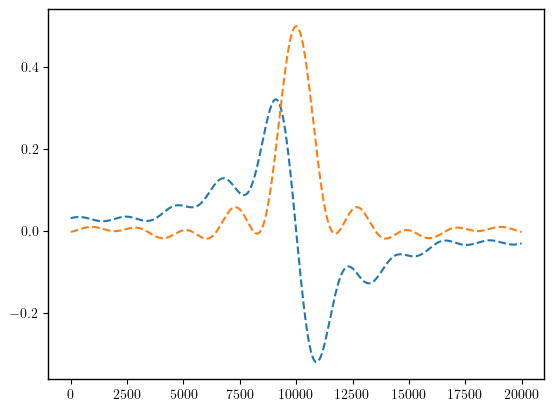

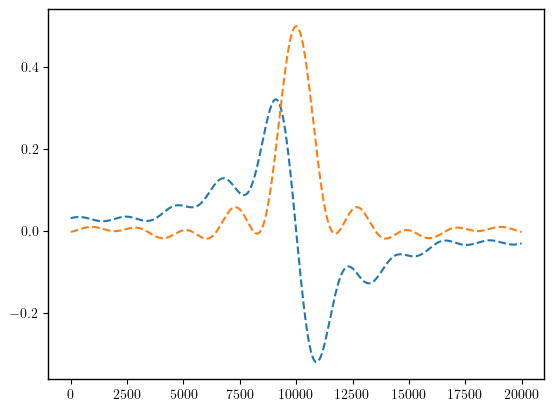

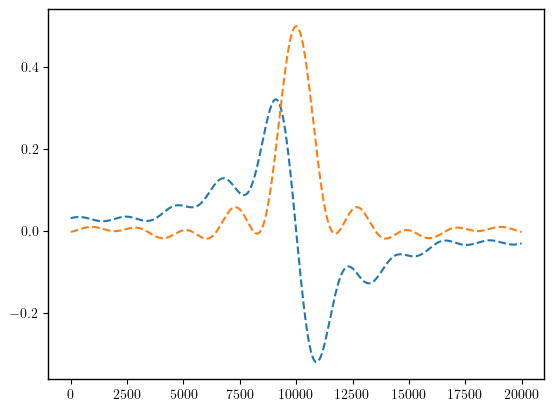

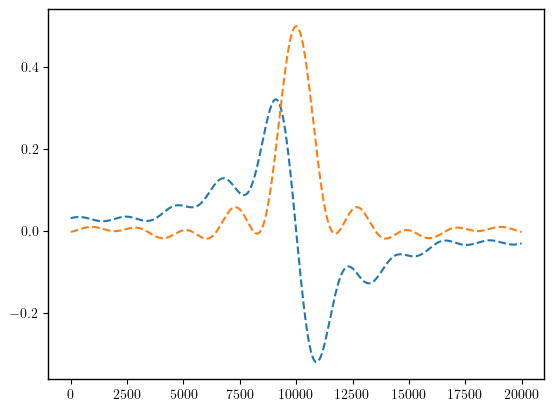

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe57cc71820>

In [119]:
s22(t,n) =  SelfL_S(t)[n,n]
plt.plot(real(s22.(ts,1)),ls = "--")
plt.plot(imag(s22.(ts,1)),ls = "--")
plt.figure()
plt.plot(real(s22.(ts,2)),ls = "--")
plt.plot(imag(s22.(ts,2)),ls = "--")
plt.figure()
plt.plot(real(s22.(ts,3)),ls = "--")
plt.plot(imag(s22.(ts,3)),ls = "--")
plt.figure()
plt.plot(real(s22.(ts,4)),ls = "--")
plt.plot(imag(s22.(ts,4)),ls = "--")

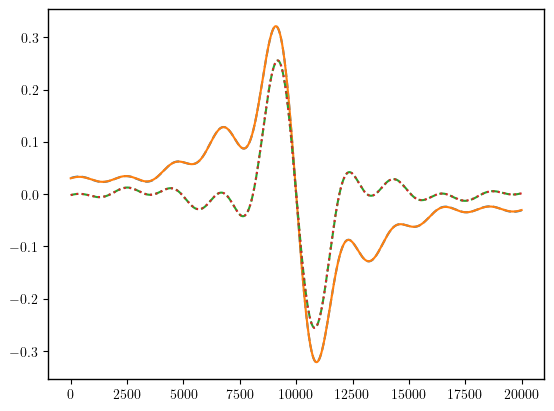

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe57d30bb00>

In [123]:
s44(t,n,m) =  SelfL_S(t)[n,m]
plt.plot(real(s44.(ts,1,1)),ls = "--")
plt.plot(real(sab.(ts,1,1))) 

plt.plot(real(s44.(ts,1,4)),ls = "--")
plt.plot(real(sab.(ts,1,3)),ls = ":") 



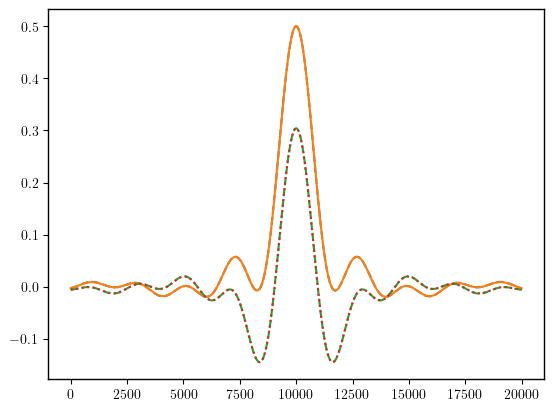

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe57db97680>

In [125]:
plt.plot(imag(s44.(ts,1,1)),ls = "--")
plt.plot(imag(sab.(ts,1,1))) 

plt.plot(imag(s44.(ts,1,4)),ls = "--")
plt.plot(imag(sab.(ts,1,3)),ls = ":") 

##Chequarar luego el gamma con cuidado

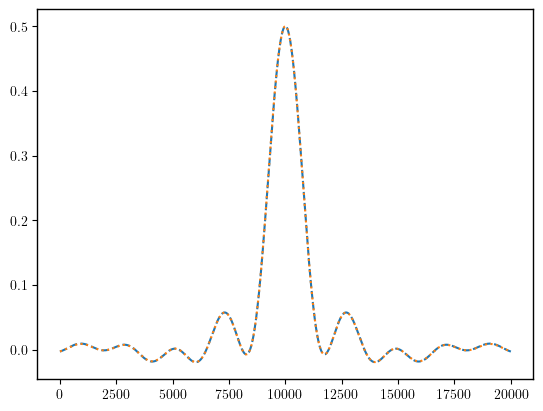

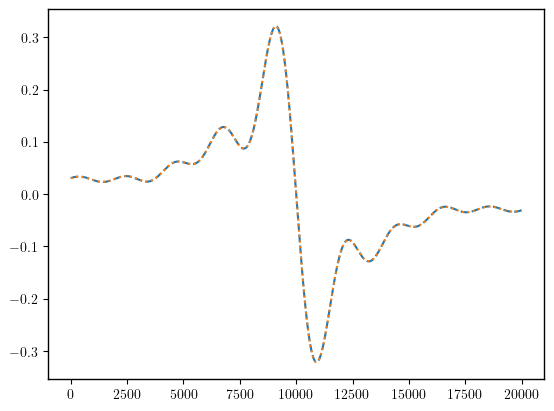

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f070db1f4d0>

In [123]:
# plt.plot(imag(s11.(ts)) )
# plt.plot(imag(s12.(ts)))
idx =4
# plt.plot(imag(s21.(ts)))
plt.plot(imag(s22.(ts,idx)),ls = "--")

plt.plot(imag(suu.(ts,idx)),ls=":")

plt.figure()
plt.plot(real(s22.(ts,idx)),ls = "--")

plt.plot(real(suu.(ts,idx)),ls=":")

# plt.plot(Es,Γ_ij.(Es;i=1,j=1,Ny=2) )
# plt.plot(Es,Γ_ij.(Es;i=1,j=2,Ny=2))
# plt.plot(Es,Γ_ij.(Es;i=1,j=3,Ny=2))
# plt.plot(Es,Γ_ij.(Es;i=1,j=4,Ny=2))
# plt.plot(Es,Γ_ij.(Es;i=1,j=5,Ny=2))